1. DATA PREPROCESSING

IMPORT LIBRARY

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

MELIHAT ISI DATASET

In [52]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [53]:
print(df.shape)

(13611, 17)


In [54]:
fitur = df.drop("Class", axis=1).values
label = df["Class"].values

print(fitur.shape)
print(label.shape)

(13611, 16)
(13611,)


Cek missing value

In [55]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Memisahkan Fitur dan Label (x,y)

In [56]:
print(fitur[:3])
print()
print(label[:3])

[[2.83950000e+04 6.10291000e+02 2.08178117e+02 1.73888747e+02
  1.19719142e+00 5.49812187e-01 2.87150000e+04 1.90141097e+02
  7.63922518e-01 9.88855999e-01 9.58027126e-01 9.13357755e-01
  7.33150614e-03 3.14728917e-03 8.34222388e-01 9.98723889e-01]
 [2.87340000e+04 6.38018000e+02 2.00524796e+02 1.82734419e+02
  1.09735646e+00 4.11785251e-01 2.91720000e+04 1.91272750e+02
  7.83968133e-01 9.84985603e-01 8.87033637e-01 9.53860842e-01
  6.97865928e-03 3.56362371e-03 9.09850506e-01 9.98430331e-01]
 [2.93800000e+04 6.24110000e+02 2.12826130e+02 1.75931143e+02
  1.20971266e+00 5.62727317e-01 2.96900000e+04 1.93410904e+02
  7.78113248e-01 9.89558774e-01 9.47849473e-01 9.08774239e-01
  7.24391184e-03 3.04773322e-03 8.25870617e-01 9.99066137e-01]]

<StringArray>
['SEKER', 'SEKER', 'SEKER']
Length: 3, dtype: str


DATA ENCODING

In [57]:
encoder = LabelEncoder()

label_encoded = encoder.fit_transform(label)
print(label[:10])
print()
print(label_encoded[:10])

<StringArray>
['SEKER', 'SEKER', 'SEKER', 'SEKER', 'SEKER', 'SEKER', 'SEKER', 'SEKER',
 'SEKER', 'SEKER']
Length: 10, dtype: str

[5 5 5 5 5 5 5 5 5 5]


In [58]:
for i, nama in enumerate(
    encoder.classes_
):
    print(i, "=",nama)

0 = BARBUNYA
1 = BOMBAY
2 = CALI
3 = DERMASON
4 = HOROZ
5 = SEKER
6 = SIRA


ONE-HOT Encoding

In [59]:
def one_hot(label_encoded):

    hasil = np.zeros(
        (
            label_encoded.size,
            label_encoded.max() + 1
        )
    )

    hasil[
        np.arange(label_encoded.size), label_encoded
    ] = 1
    return hasil

In [60]:
label_onehot = one_hot(label_encoded)
print(
label_onehot.shape
)

print()

print(
label_onehot[:5]
)

(13611, 7)

[[0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]]


Standarisasi Data

In [61]:
scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)

print(fitur[:3])
print()
print(fitur_scaled[:3])
print(fitur_scaled.shape)
print(label_onehot.shape)

[[2.83950000e+04 6.10291000e+02 2.08178117e+02 1.73888747e+02
  1.19719142e+00 5.49812187e-01 2.87150000e+04 1.90141097e+02
  7.63922518e-01 9.88855999e-01 9.58027126e-01 9.13357755e-01
  7.33150614e-03 3.14728917e-03 8.34222388e-01 9.98723889e-01]
 [2.87340000e+04 6.38018000e+02 2.00524796e+02 1.82734419e+02
  1.09735646e+00 4.11785251e-01 2.91720000e+04 1.91272750e+02
  7.83968133e-01 9.84985603e-01 8.87033637e-01 9.53860842e-01
  6.97865928e-03 3.56362371e-03 9.09850506e-01 9.98430331e-01]
 [2.93800000e+04 6.24110000e+02 2.12826130e+02 1.75931143e+02
  1.20971266e+00 5.62727317e-01 2.96900000e+04 1.93410904e+02
  7.78113248e-01 9.89558774e-01 9.47849473e-01 9.08774239e-01
  7.24391184e-03 3.04773322e-03 8.25870617e-01 9.99066137e-01]]

[[-0.84074853 -1.1433189  -1.30659814 -0.63115304 -1.56505251 -2.18572039
  -0.84145059 -1.0633406   0.28908744  0.36761343  1.42386707  1.8391164
   0.68078638  2.40217287  1.92572347  0.83837103]
 [-0.82918764 -1.01392388 -1.39591111 -0.43444458 -1.

Split Dataset (80% training, 20% testing)

In [62]:
X_train,\
X_test,\
Y_train,\
Y_test = train_test_split(
    fitur_scaled,
    label_onehot,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(10888, 16)
(2723, 16)
(10888, 7)
(2723, 7)


2. MODELLING (Membuat model awal Baseline)

Inisialisasi Parameter (Bobot dan bias)
Disini saya menggunakan 5 metode yaitu 
1. zero
2. uniform
3. Normal
4. Xavier
5. He

In [63]:
# INISIALISASI BOBOT (WEIGHT INITIALIZATION)
# Mengunci angka random agar hasil eksperimen selalu konsisten setiap program dijalankan
np.random.seed(42)

# Zero Initialization, semua bobot diisi nilai 0
def zero_init(shape):
    return np.zeros(shape)

# Uniform Initialization
# Bobot diisi angka acak dengan distribusi uniform rentang -0.5 sampai 0.5
def uniform_init(shape):
    return np.random.uniform(-0.5, 0.5, shape)

# Normal Initialization
# Bobot diisi angka acak distribusi normal(mean = 0, std = 1)
def normal_init(shape):
    return np.random.randn(*shape)

# Xavier Initialization
def xavier_init(shape):
    return (np.random.randn(*shape) * np.sqrt(1 / shape[0]))

# He Initialization
def he_init(shape):
    return (np.random.randn(*shape) * np.sqrt(2 / shape[0]))

Implementasi forward propagation untuk FCL

In [64]:
# Implementasi Forward Propagation untuk FCL
def forward_fcl(X, W, b):
    # Operasi linear
    Z = (X @ W + b)
    return Z
# Inisialisasi Parameter (IMPLEMENTASI AWAL)
W = uniform_init((16,16))
b = zero_init((1,16))

Implementasi Fungsi Aktivasi saya menggunakan Sigmoid, ReLU, Tanh, dan Softmax(untuk output layer)

In [65]:
# Fungsi Aktivasi Hidden
def sigmoid(Z):
    return (1 / (1 + np.exp(-Z)))


def relu(Z):
    return np.maximum(0,Z)


def tanh(Z):
    return np.tanh(Z)


def softmax(Z):
    exp = np.exp(Z - np.max(Z,axis=1,keepdims=True))
    return (exp / np.sum(exp, axis=1, keepdims=True))

# Menjalankan Aktivasi
Z = forward_fcl(X_train, W, b)
A = relu(Z)
print(A[:5])

[[1.08152419 0.         0.         0.         0.86156083 1.46788526
  0.10331382 0.07535007 0.23388621 0.         1.56939059 0.
  0.134516   0.55413619 0.         0.94251804]
 [0.90858212 0.         0.         0.         1.27188922 0.51596464
  0.         0.43258444 0.6518874  0.         0.5353466  0.01144467
  0.         0.59454432 0.         0.73187055]
 [0.         0.         1.01177586 0.         0.84483091 0.65452438
  0.7386528  0.         0.         0.         2.06900497 0.
  0.08328781 0.26548071 0.         0.88672255]
 [0.         0.         0.33467372 0.         0.         0.70717315
  0.9058634  0.         0.         0.         1.46026671 0.
  0.78083998 0.09908409 0.         0.45842892]
 [0.         0.         1.0494345  0.         0.         0.47785787
  0.97361973 0.15559189 0.13975442 0.2270737  1.19249933 0.01255208
  0.7831017  0.         0.         0.54714816]]


In [66]:
# Implementasi FCL Output Layer
output_size = 7
# Membuat bobot output
W2 = he_init((A.shape[1], output_size))


# Membuat bias output
b2 = np.zeros((1, output_size))
# Forward FCL Output
Z2 = forward_fcl(A, W2, b2)

# Aktivasi Output (Softmax)
A2 = softmax(Z2)

# Cek hasil
print("Shape Output:", A2.shape)
print()
print(A2[:5])

Shape Output: (10888, 7)

[[0.12237955 0.01920027 0.19182284 0.11036841 0.05962904 0.14257317
  0.35402673]
 [0.13712992 0.04074683 0.17433424 0.26571343 0.07490438 0.0961638
  0.21100739]
 [0.07988402 0.0609108  0.25699883 0.11330991 0.0807951  0.14003033
  0.26807101]
 [0.05262301 0.0494554  0.17626873 0.08584314 0.08496784 0.11556288
  0.43527901]
 [0.05192891 0.14570019 0.17501549 0.11884078 0.10081464 0.08743719
  0.32026279]]


diperoleh output (10888, 7) yang berarti 10.888 data training dan 7 kelas output

Implementasi perhitungan Loss MSE

In [67]:
# Mean Squared Error (MSE)
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

loss = mse_loss(Y_train, A2)

print("MSE Loss:", loss)

MSE Loss: 0.1351643128817607


Implementasi perhitungan loss Binary Cross Entropy

In [68]:
# Binary Cross Entropy (BCE)
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-10
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
loss_bce = binary_cross_entropy(Y_train, A2)

print("Binary Cross Entropy:", loss_bce)

Binary Cross Entropy: 0.45741252665010923


Implementasi perhitungan loss Multiclass Binary Entropy

In [69]:
# Multiclass Cross Entropy
def multiclass_cross_entropy(y_true, y_pred):
    epsilon = 1e-10

    return -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))

loss_mce = multiclass_cross_entropy(Y_train, A2)

print("Multiclass Cross Entropy:", loss_mce)

Multiclass Cross Entropy: 2.2101759103734087


Implementasi Backpropagation

In [70]:
# Implementasi Backpropagation
def backpropagation(A, A2, Y, W2):
    m = Y.shape[0]

    # Error output
    dZ2 = (A2 - Y)

    # Gradient bobot
    dW2 = (A.T @ dZ2) / m


    # Gradient bias
    db2 = (np.sum(dZ2, axis=0, keepdims=True)) / m

    return (dW2, db2)

# Menjalankan Backpropagation
dW2,\
db2 = backpropagation(A, A2, Y_train, W2)

print("Shape dW2:", dW2.shape)
print("Shape db2:", db2.shape)
# dW2 = Turunan loss terhadap bobot
# Dipakai untuk mengetahui seberapa besar bobot harus diperbaiki

# db2 = Turunan loss terhadap bias
# Dipakai untuk mengetahui seberapa besar bias harus diperbaiki

Shape dW2: (16, 7)
Shape db2: (1, 7)


Update bobot (gradient descent)

In [71]:
# Update Parameter (Gradient Descent)
def update_parameter(W2, b2, dW2, db2, learning_rate=0.01):
    # Update bobot
    W2 = (W2 - learning_rate * dW2)

    # Update bias
    b2 = (b2 - learning_rate * db2)

    return (W2, b2)

# Menjalankan Update Parameter
W2,\
b2 = update_parameter(W2, b2, dW2, db2, learning_rate=0.01)

print("Shape W2:", W2.shape)
print("Shape b2:", b2.shape)

Shape W2: (16, 7)
Shape b2: (1, 7)


Training model awal
Epoch 100
Pada setiap epoch dilakukan Forward Propagation, perhitungan Loss, Backpropagation, dan Update Parameter.
dilihat dari hasil loss terus menurun jadi kesimpulannya model sudah bekerja dan memperbaiki kesalahan

In [72]:
# Training Loop
epoch = 100
learning_rate = 0.01

loss_history = []
for i in range(epoch):
    # ===== FORWARD =====

    # Fully Connected Layer
    Z = forward_fcl(X_train, W, b)


    # Aktivasi Hidden Layer
    A = relu(Z)

    # Output Layer
    Z2 = forward_fcl(A, W2, b2)


    # Softmax
    A2 = softmax(Z2)


    # ===== LOSS =====

    loss = multiclass_cross_entropy(Y_train, A2)
    loss_history.append(loss)

    # ===== BACKPROP =====
    dW2,\
    db2 = backpropagation(A, A2, Y_train, W2)


    # ===== UPDATE =====
    W2,\
    b2 = update_parameter(W2, b2, dW2, db2, learning_rate)

    # Print tiap 10 epoch
    if i % 10 == 0:
        print("Epoch", i, "| Loss:", round(loss, 4))

Epoch 0 | Loss: 2.2016
Epoch 10 | Loss: 2.1191
Epoch 20 | Loss: 2.042
Epoch 30 | Loss: 1.9701
Epoch 40 | Loss: 1.9033
Epoch 50 | Loss: 1.8413
Epoch 60 | Loss: 1.784
Epoch 70 | Loss: 1.7311
Epoch 80 | Loss: 1.6823
Epoch 90 | Loss: 1.6372


GRAFIK LOSS vs EPOCH

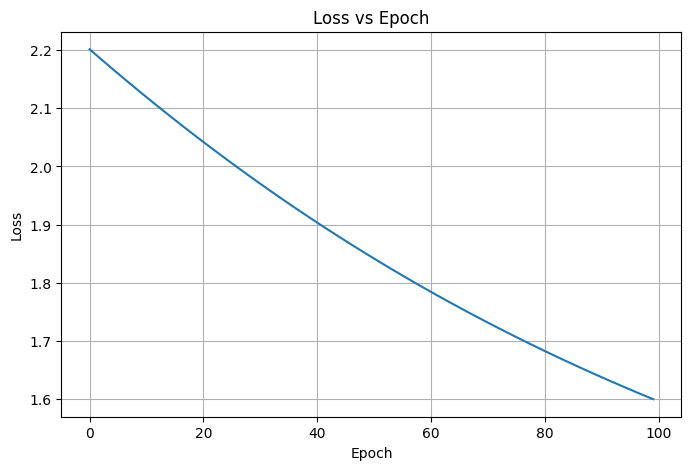

In [73]:
# Visualisasi Loss
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [74]:
# Evaluasi Accuracy
# Ambil kelas prediksi
pred = np.argmax(A2, axis=1)

# Ambil kelas label asli
true = np.argmax(Y_train, axis=1)

# Hitung accuracy
accuracy = np.mean(pred == true)

print("Accuracy:", round(accuracy * 100, 2),"%")

Accuracy: 30.86 %


Evaluasi 
Hasil akurasi dari model awal (masih menggunakan bobot random): 30.86 %
Setelah ini baru masuk ke tahap eksperimen

3. EKSPERIMEN

Eksperimen 1.a Hidden layer (1, 2, 3)

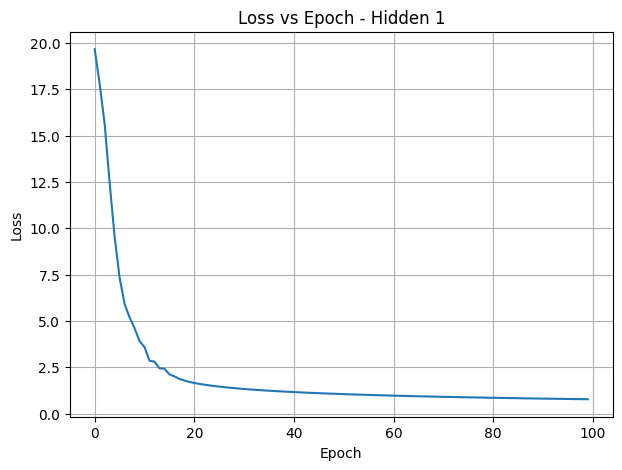

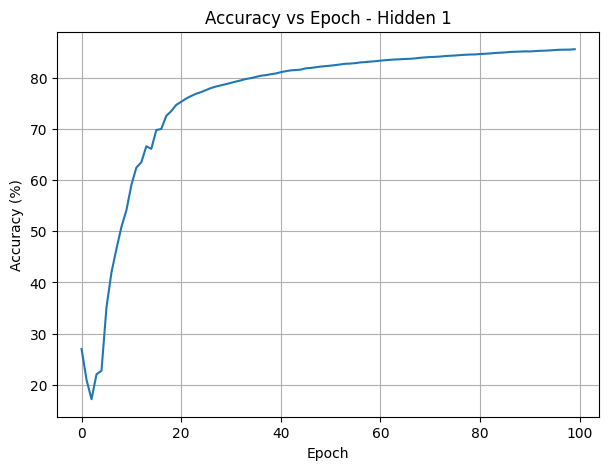

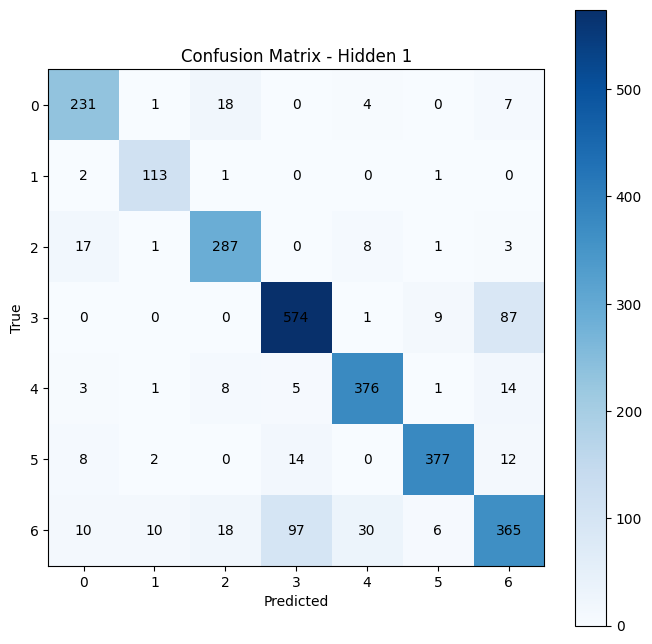

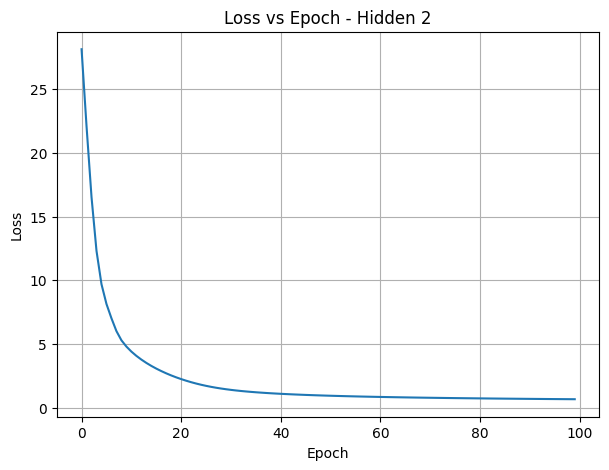

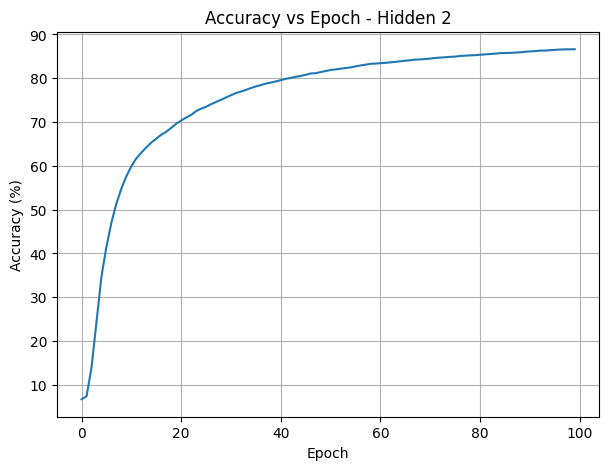

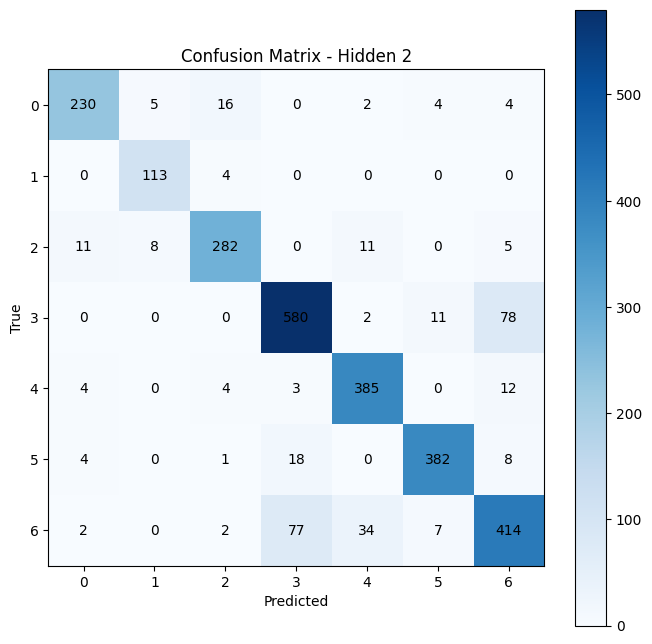

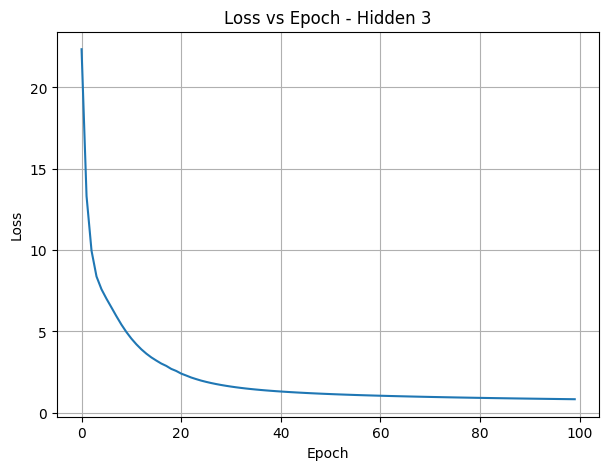

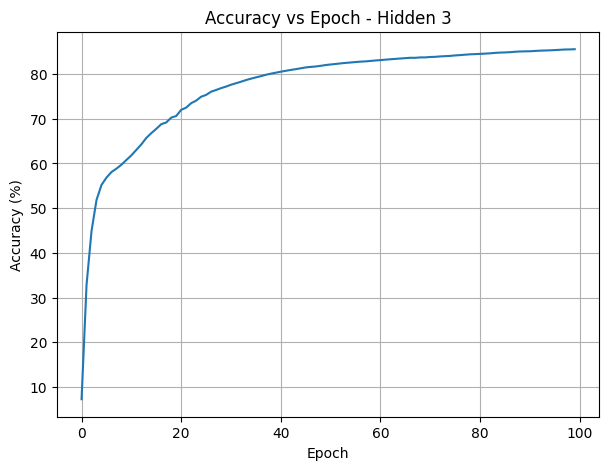

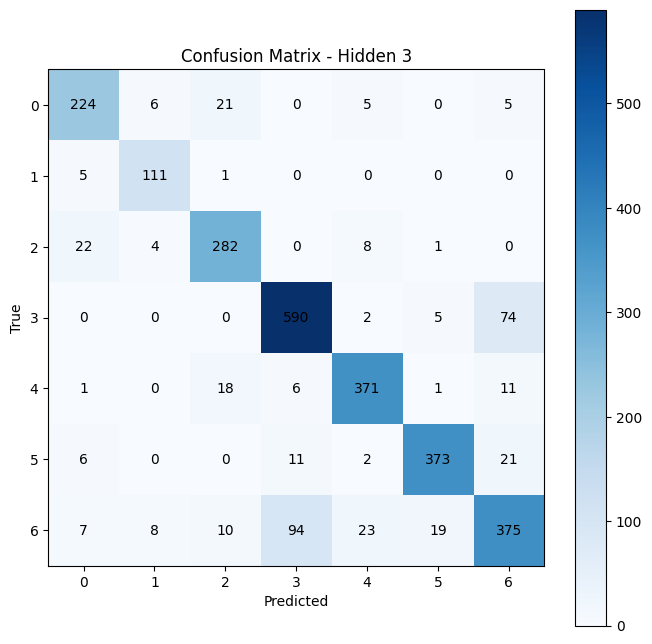


Hidden     | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
1          | 0.774        | 85.57           | 0.7972       | 85.31       
2          | 0.6545       | 86.62           | 0.5796       | 87.62       
3          | 0.8354       | 85.52           | 0.8051       | 85.42       


In [ ]:
# ==========================================================
# EKSPERIMEN A - HIDDEN LAYER
# ==========================================================
hidden_list = [1, 2, 3]

hasil_hidden = []


for hidden in hidden_list:


    # ==================================
    # INISIALISASI
    # ==================================

    W = normal_init((16,128))
    b = zero_init((1,128))

    W2 = normal_init((128,7))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    # ==================================
    # TRAINING
    # ==================================

    for epoch in range(100):


        Z = forward_fcl(
            X_train,
            W,
            b
        )

        A = relu(
            Z
        )


        Z2 = forward_fcl(
            A,
            W2,
            b2
        )

        A2 = softmax(
            Z2
        )


        loss = multiclass_cross_entropy(
            Y_train,
            A2
        )


        dW2, db2 = backpropagation(

            A,

            A2,

            Y_train,

            W2

        )


        W2, b2 = update_parameter(

            W2,

            b2,

            dW2,

            db2,

            learning_rate=0.1

        )


        pred_train = np.argmax(
            A2,
            axis=1
        )


        true_train = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(

            pred_train
            ==
            true_train

        )*100


        loss_history.append(
            loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================================
    # TRAIN EVALUATION
    # ==================================

    train_loss = loss


    # ==================================
    # TEST
    # ==================================

    Z_test = forward_fcl(
        X_test,
        W,
        b
    )

    A_test = relu(
        Z_test
    )

    Z2_test = forward_fcl(
        A_test,
        W2,
        b2
    )

    A2_test = softmax(
        Z2_test
    )


    test_loss = multiclass_cross_entropy(
        Y_test,
        A2_test
    )


    pred_test = np.argmax(
        A2_test,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(

        pred_test
        ==
        true_test

    )*100


    hasil_hidden.append([

        hidden,

        round(train_loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])



    # ==================================
    # GRAFIK LOSS
    # ==================================

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch - Hidden {hidden}"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.grid()

    plt.show()



    # ==================================
    # GRAFIK ACCURACY
    # ==================================

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - Hidden {hidden}"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.grid()

    plt.show()



    # ==================================
    # CONFUSION MATRIX
    # ==================================

    cm = np.zeros(
        (
            7,
            7
        ),
        dtype=int
    )


    for t,p in zip(

        true_test,

        pred_test

    ):

        cm[t][p]+=1


    plt.figure(
        figsize=(8,8)
    )


    plt.imshow(
        cm,
        cmap="Blues"
    )

    plt.colorbar()


    for i in range(7):

        for j in range(7):

            plt.text(

                j,

                i,

                cm[i,j],

                ha="center",

                va="center"

            )


    plt.title(
        f"Confusion Matrix - Hidden {hidden}"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.show()



# ==================================================
# TABEL HASIL
# ==================================================

print()

print(
f"{'Hidden':<10} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_hidden:

    print(

        f"{h[0]:<10} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen jumlah hidden layer, model dengan 2 hidden layer menghasilkan performa terbaik dengan training accuracy sebesar 86,62% dan testing accuracy sebesar 87,62%. Nilai loss juga menjadi yang paling rendah dibanding konfigurasi lainnya. Penambahan hidden layer hingga 3 tidak meningkatkan performa, sehingga dapat disimpulkan bahwa penambahan kompleksitas jaringan secara berlebihan belum tentu menghasilkan akurasi yang lebih baik.

Eksperimen 1.b jumlah neuron per layer (16, 32, 64, 128)

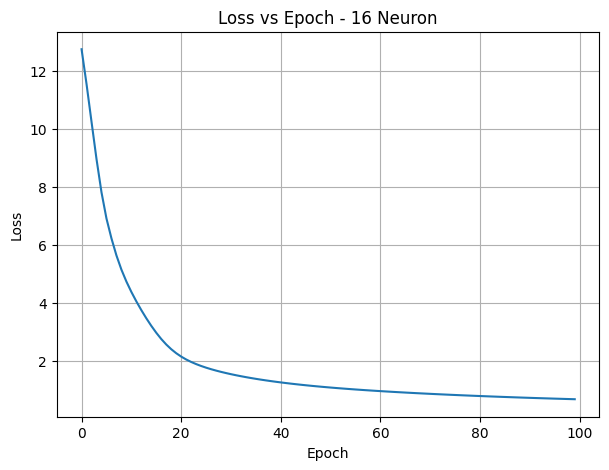

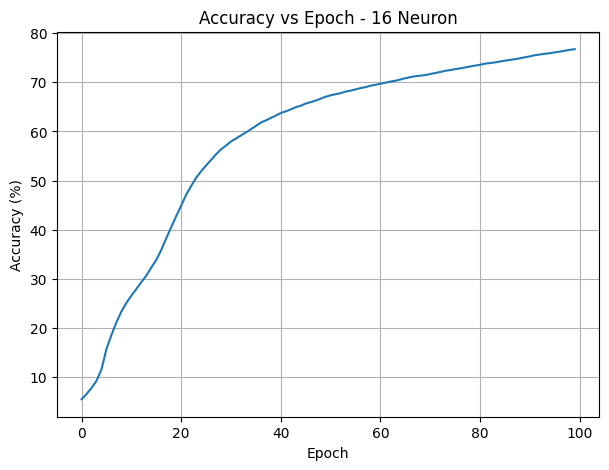

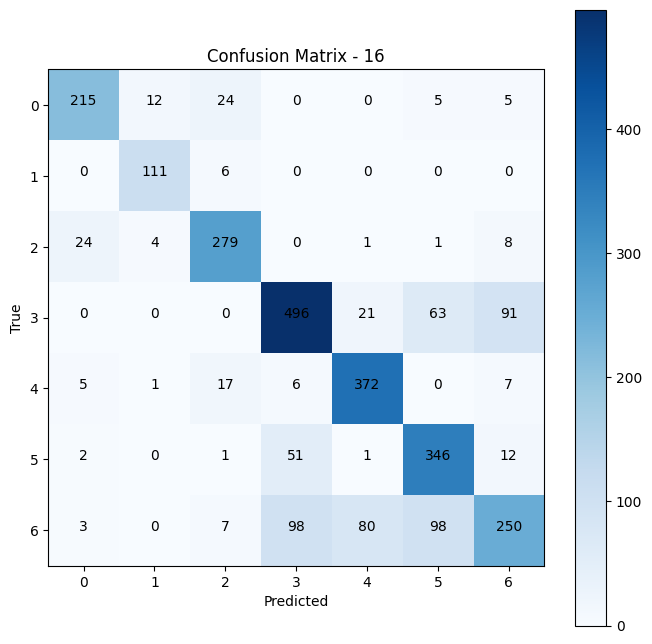

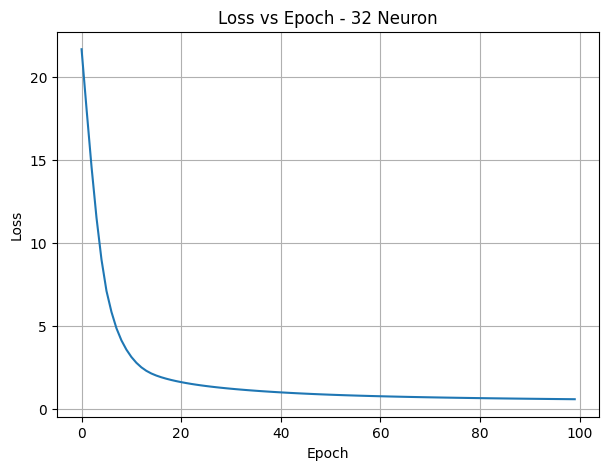

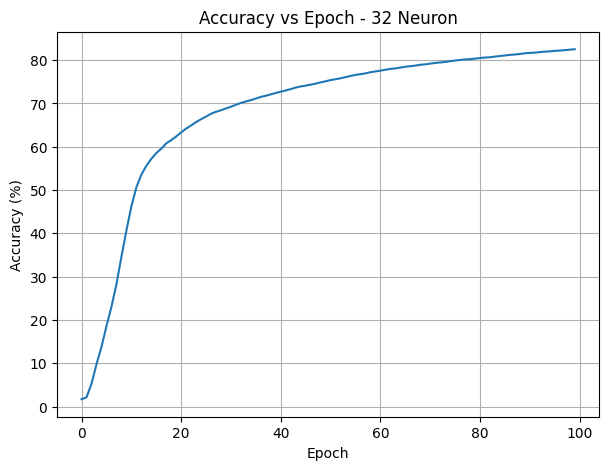

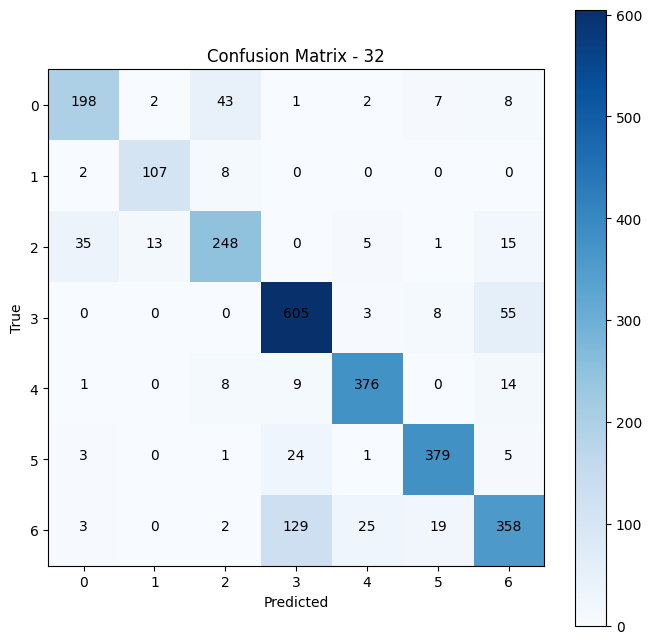

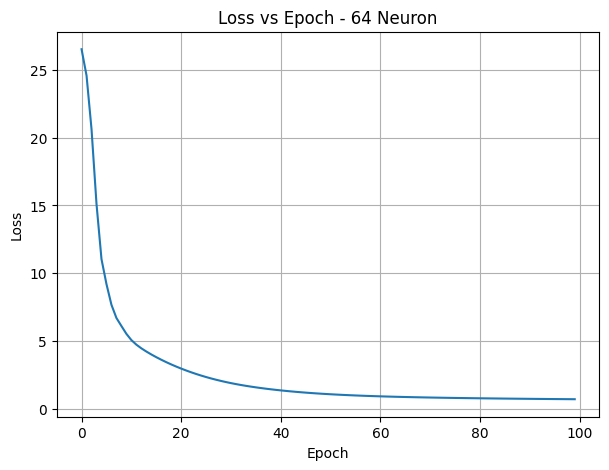

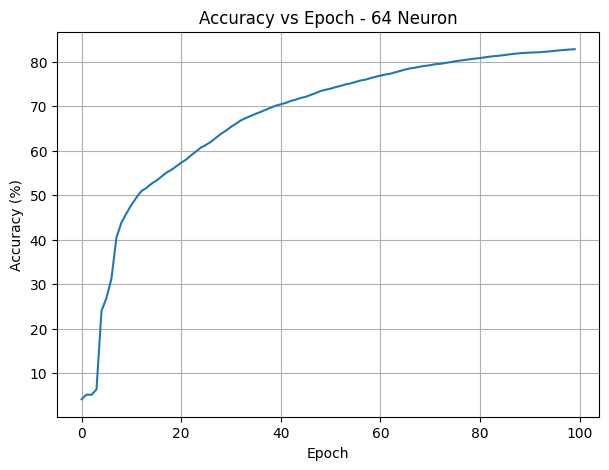

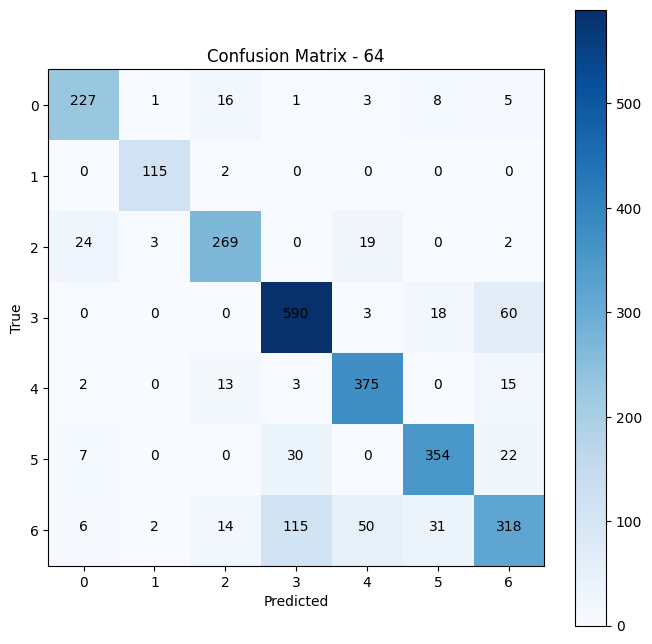

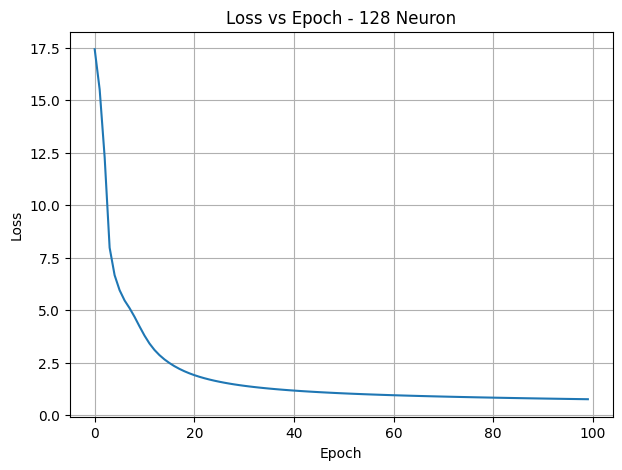

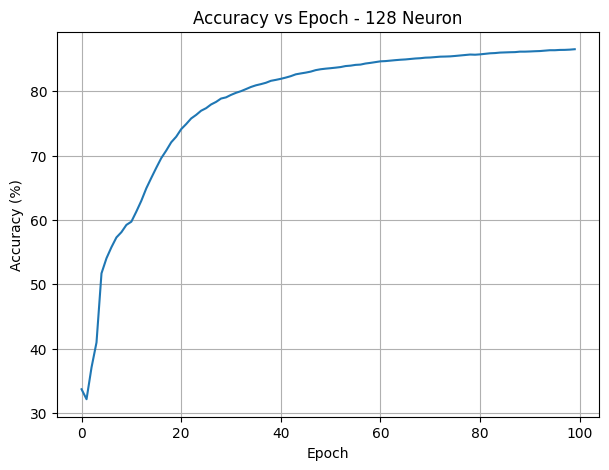

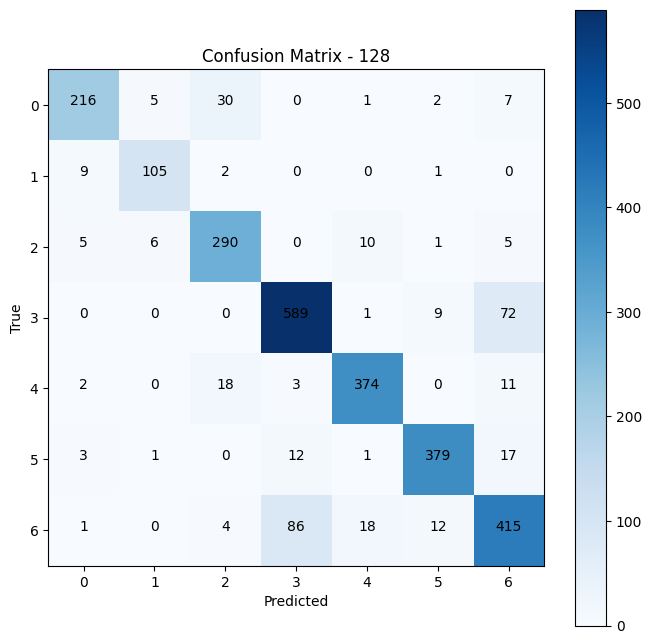


Neuron     | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
16         | 0.6945       | 76.73           | 0.6961       | 75.98       
32         | 0.602        | 82.5            | 0.568        | 83.4        
64         | 0.6877       | 82.83           | 0.684        | 82.56       
128        | 0.7536       | 86.55           | 0.6857       | 86.96       


In [ ]:
# ==========================================================
# EKSPERIMEN B - JUMLAH NEURON
# + TRAIN TEST
# + VISUALISASI
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


neuron_list = [16,32,64,128]

hasil_neuron = []


for neuron in neuron_list:


    # ==========================
    # INISIALISASI
    # ==========================

    W = normal_init((16, neuron))
    b = zero_init((1, neuron))

    W2 = normal_init((neuron, 7))
    b2 = zero_init((1, 7))


    loss_history = []
    accuracy_history = []


    # ==========================
    # TRAINING
    # ==========================

    for epoch in range(100):


        Z = forward_fcl(
            X_train,
            W,
            b
        )

        A = relu(
            Z
        )


        Z2 = forward_fcl(
            A,
            W2,
            b2
        )

        A2 = softmax(
            Z2
        )


        loss = multiclass_cross_entropy(
            Y_train,
            A2
        )


        dW2, db2 = backpropagation(

            A,

            A2,

            Y_train,

            W2

        )


        W2, b2 = update_parameter(

            W2,

            b2,

            dW2,

            db2,

            learning_rate=0.1

        )


        pred_train = np.argmax(
            A2,
            axis=1
        )


        true_train = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(
            pred_train
            ==
            true_train
        )*100


        loss_history.append(
            loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==========================
    # TEST
    # ==========================

    Z = forward_fcl(
        X_test,
        W,
        b
    )

    A = relu(
        Z
    )

    Z2 = forward_fcl(
        A,
        W2,
        b2
    )

    A2 = softmax(
        Z2
    )


    test_loss = multiclass_cross_entropy(
        Y_test,
        A2
    )


    pred_test = np.argmax(
        A2,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(
        pred_test
        ==
        true_test
    )*100


    hasil_neuron.append([

        neuron,

        round(loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # ==========================
    # LOSS
    # ==========================

    plt.figure(figsize=(7,5))

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch - {neuron} Neuron"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.grid()

    plt.show()



    # ==========================
    # ACCURACY
    # ==========================

    plt.figure(figsize=(7,5))

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - {neuron} Neuron"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.grid()

    plt.show()



    # ==========================
    # CONFUSION MATRIX
    # ==========================

    cm = np.zeros(
        (
            7,
            7
        ),
        dtype=int
    )


    for t,p in zip(
        true_test,
        pred_test
    ):

        cm[t][p]+=1


    plt.figure(
        figsize=(8,8)
    )

    plt.imshow(
        cm,
        cmap="Blues"
    )

    plt.colorbar()


    for i in range(7):

        for j in range(7):

            plt.text(
                j,
                i,
                cm[i,j],
                ha="center"
            )


    plt.title(f"Confusion Matrix - {neuron}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()



print()

print(
f"{'Neuron':<10} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_neuron:

    print(

        f"{h[0]:<10} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen jumlah neuron, peningkatan jumlah neuron cenderung meningkatkan kemampuan model dalam mempelajari pola data. Konfigurasi 128 neuron memberikan performa terbaik dengan training accuracy sebesar 86,55% dan testing accuracy sebesar 86,96%. Hal ini menunjukkan bahwa jumlah neuron yang lebih besar mampu menangkap representasi fitur yang lebih kompleks tanpa menyebabkan penurunan performa pada data testing. ada indikasi underfitting pada neuron 16 karena akurasinya rendah

EKSPERIMEN 2 — Perbandingan Inisialisasi Bobot
metode yang di uji : 
1. Zero
2. Uniform
3. Normal
4. Xavier
5. He

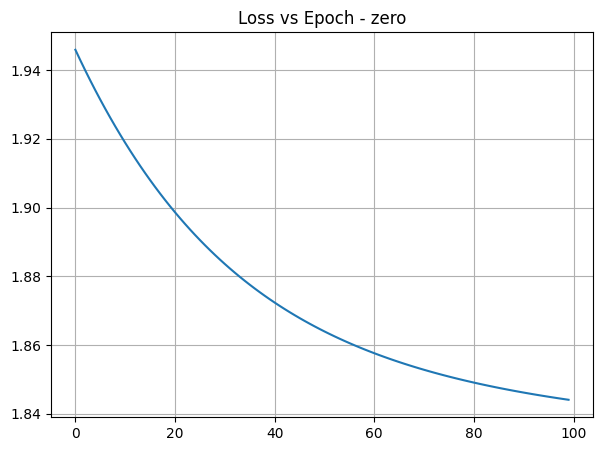

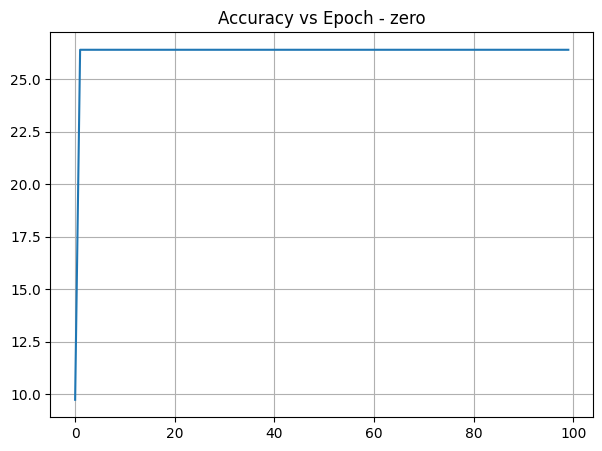

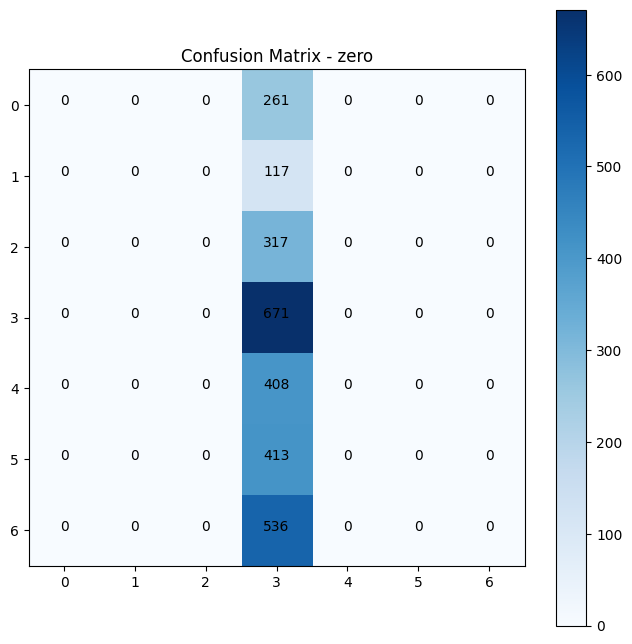

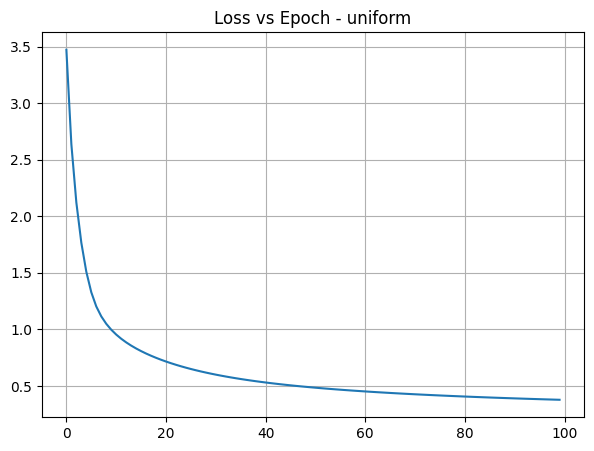

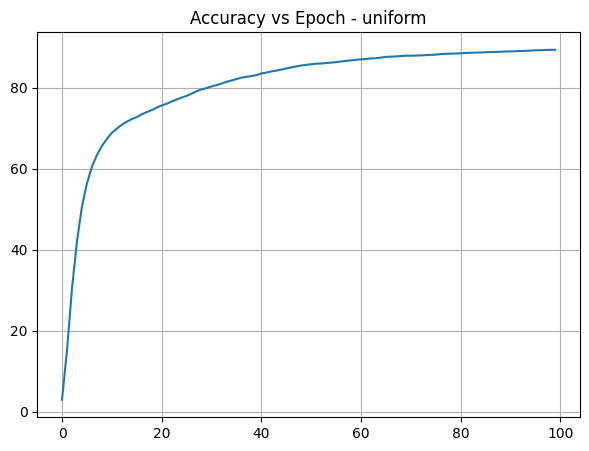

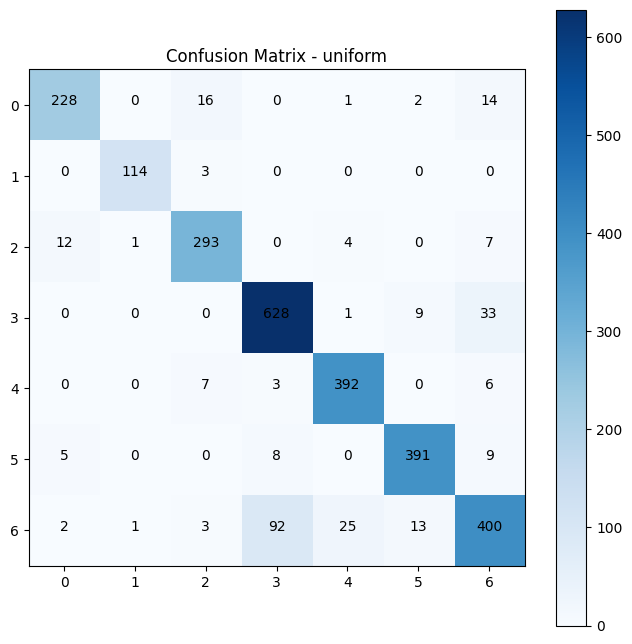

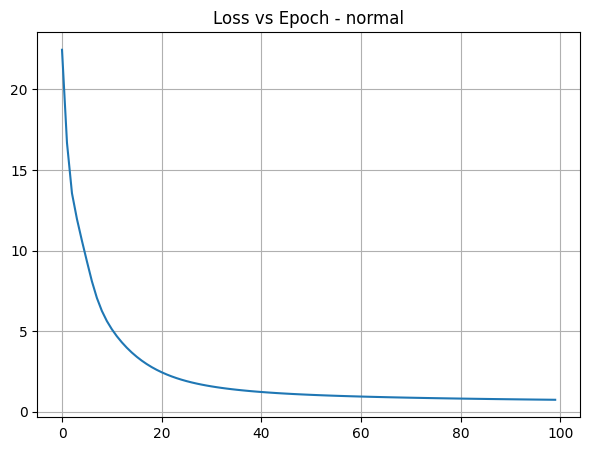

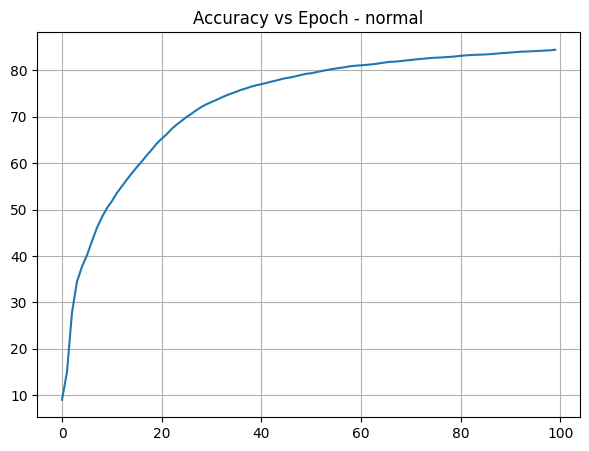

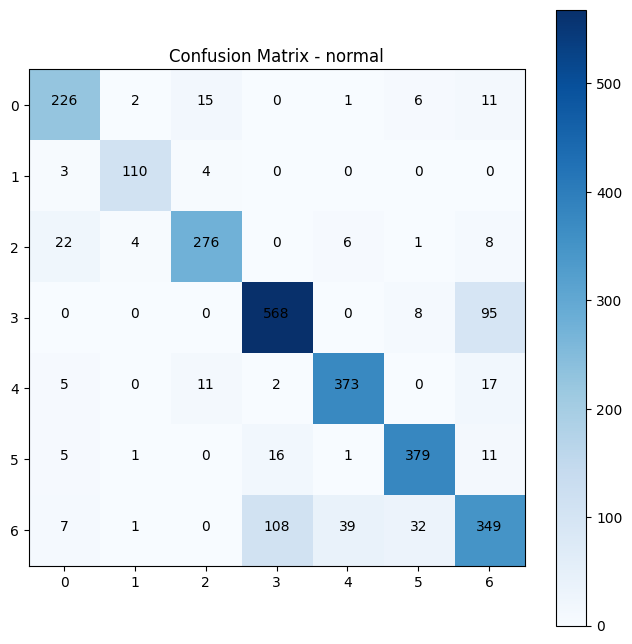

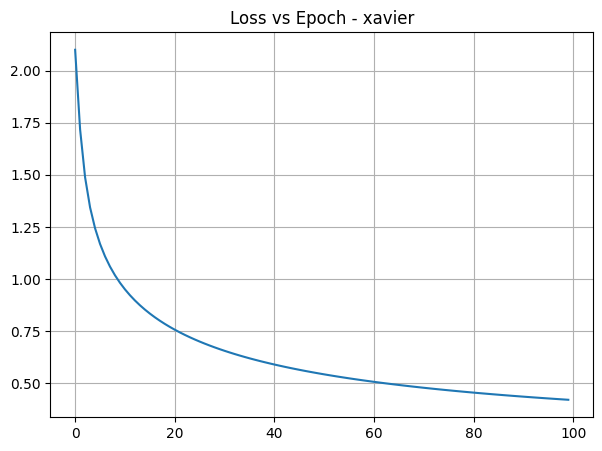

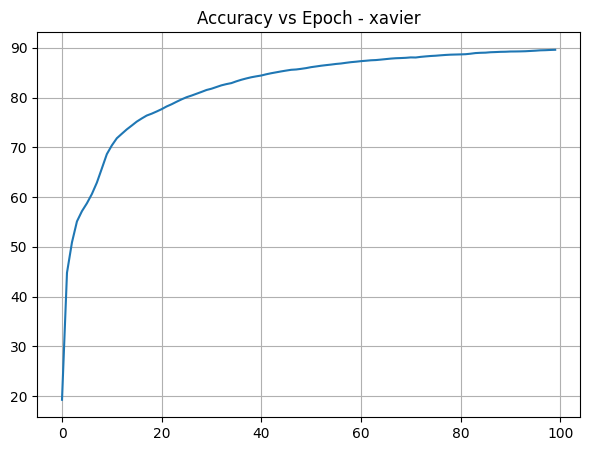

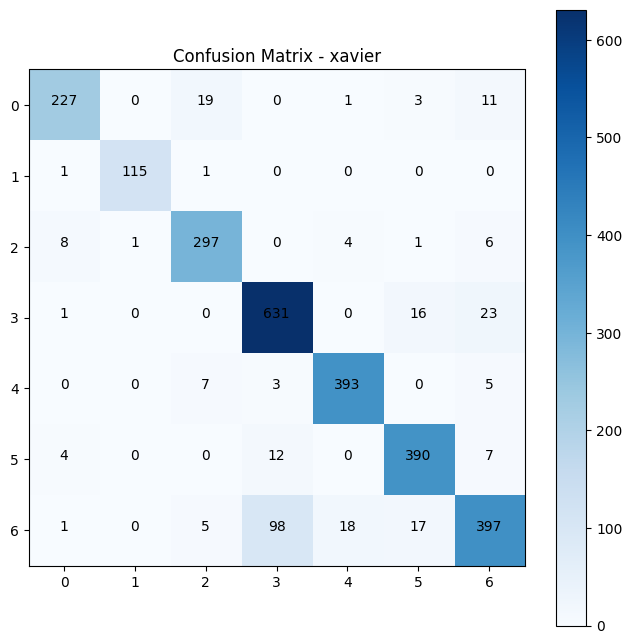

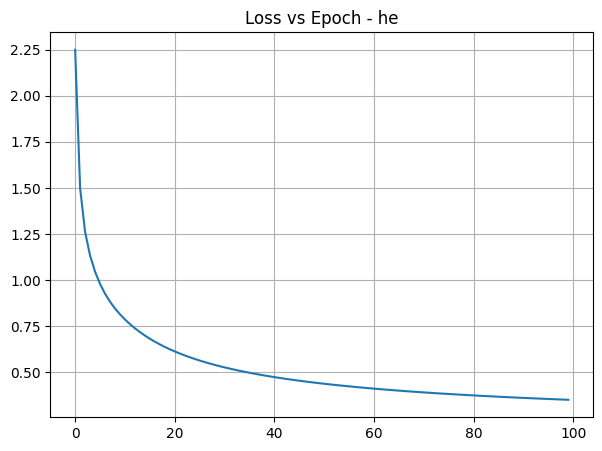

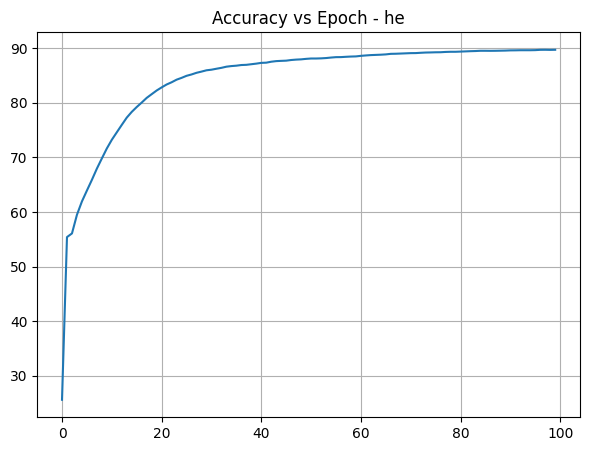

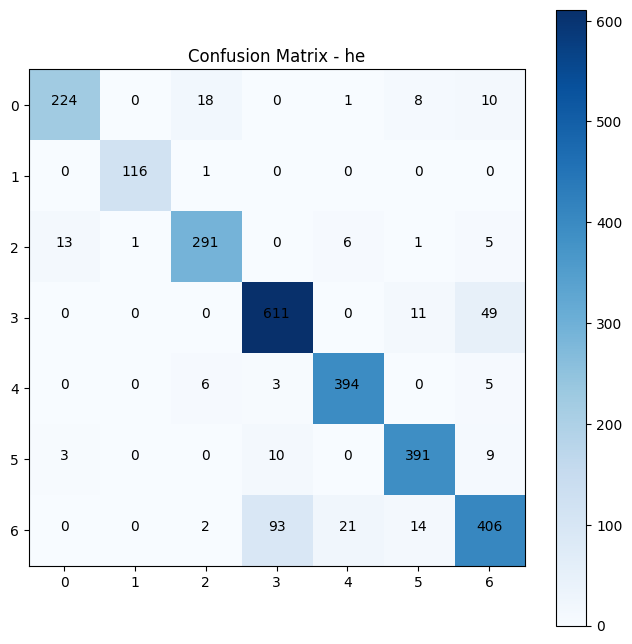


Init         | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
zero         | 1.8441       | 26.41           | 1.8557       | 24.64       
uniform      | 0.3783       | 89.39           | 0.3739       | 89.83       
normal       | 0.7485       | 84.43           | 0.7818       | 83.77       
xavier       | 0.4202       | 89.61           | 0.418        | 89.97       
he           | 0.3495       | 89.71           | 0.35         | 89.35       


In [99]:
# ==========================================================
# EKSPERIMEN C - INISIALISASI BOBOT
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


init_list = [

    "zero",

    "uniform",

    "normal",

    "xavier",

    "he"

]


hasil_init = []


for init in init_list:


    # ==================================
    # INISIALISASI
    # ==================================

    if init=="zero":

        W = zero_init((16,128))
        W2 = zero_init((128,7))


    elif init=="uniform":

        W = uniform_init((16,128))
        W2 = uniform_init((128,7))


    elif init=="normal":

        W = normal_init((16,128))
        W2 = normal_init((128,7))


    elif init=="xavier":

        W = xavier_init((16,128))
        W2 = xavier_init((128,7))


    elif init=="he":

        W = he_init((16,128))
        W2 = he_init((128,7))


    b = zero_init((1,128))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    # ==================================
    # TRAINING
    # ==================================

    for epoch in range(100):


        Z = forward_fcl(
            X_train,
            W,
            b
        )


        A = relu(
            Z
        )


        Z2 = forward_fcl(
            A,
            W2,
            b2
        )


        A2 = softmax(
            Z2
        )


        loss = multiclass_cross_entropy(
            Y_train,
            A2
        )


        dW2, db2 = backpropagation(

            A,

            A2,

            Y_train,

            W2

        )


        W2, b2 = update_parameter(

            W2,

            b2,

            dW2,

            db2,

            learning_rate=0.1

        )


        pred = np.argmax(
            A2,
            axis=1
        )

        true = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(
            pred==true
        )*100


        loss_history.append(
            loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================================
    # TEST
    # ==================================

    Z = forward_fcl(
        X_test,
        W,
        b
    )

    A = relu(
        Z
    )

    Z2 = forward_fcl(
        A,
        W2,
        b2
    )

    A2 = softmax(
        Z2
    )


    test_loss = multiclass_cross_entropy(
        Y_test,
        A2
    )


    pred_test = np.argmax(
        A2,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(
        pred_test
        ==
        true_test
    )*100


    hasil_init.append([

        init,

        round(loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # ==================
    # LOSS
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch - {init}"
    )

    plt.grid()

    plt.show()



    # ==================
    # ACCURACY
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - {init}"
    )

    plt.grid()

    plt.show()



    # ==================
    # CONFUSION MATRIX
    # ==================

    cm = np.zeros(
        (
            7,
            7
        ),
        dtype=int
    )


    for t,p in zip(

        true_test,

        pred_test

    ):

        cm[t][p]+=1


    plt.figure(
        figsize=(8,8)
    )

    plt.imshow(
        cm,
        cmap="Blues"
    )

    plt.colorbar()


    for i in range(7):

        for j in range(7):

            plt.text(
                j,
                i,
                cm[i,j],
                ha="center"
            )


    plt.title(
        f"Confusion Matrix - {init}"
    )

    plt.show()



# ==================================
# HASIL
# ==================================

print()

print(
f"{'Init':<12} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_init:

    print(

        f"{h[0]:<12} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen inisialisasi bobot, metode Xavier menghasilkan performa terbaik dengan training accuracy sebesar 89,61% dan testing accuracy sebesar 89,97%. Nilai loss pada data training dan testing juga relatif kecil dan stabil.

Eksperimen 3 fungsi aktivasi

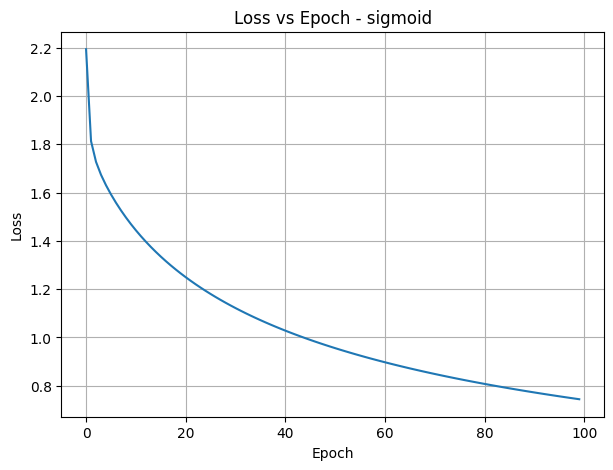

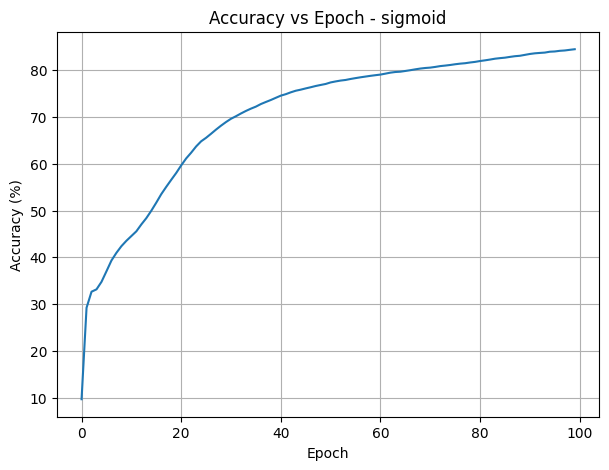

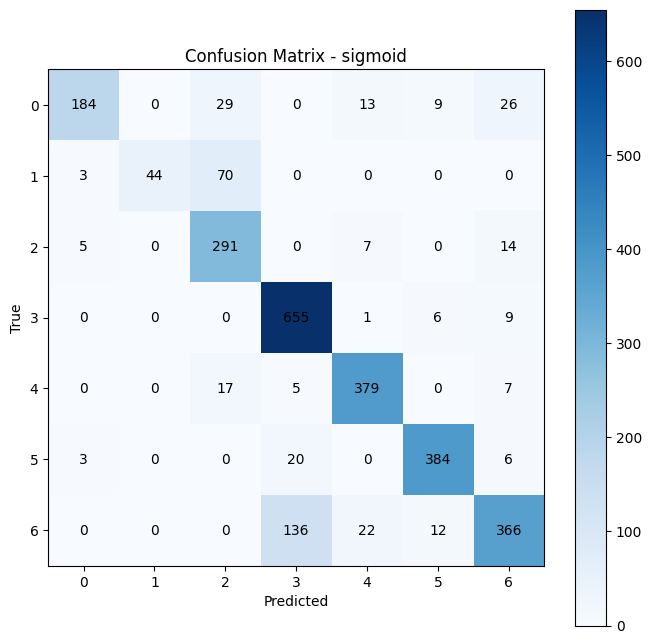

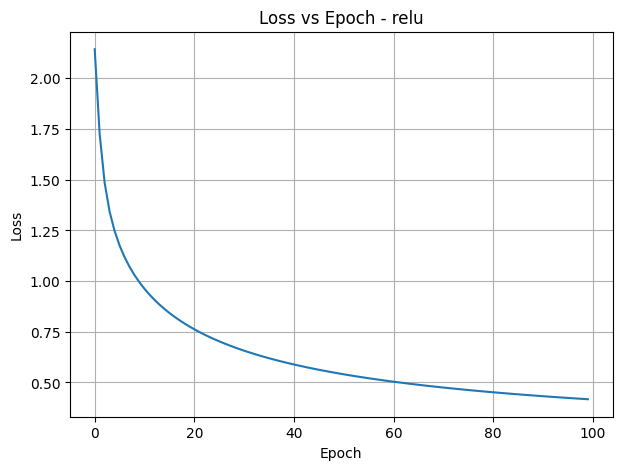

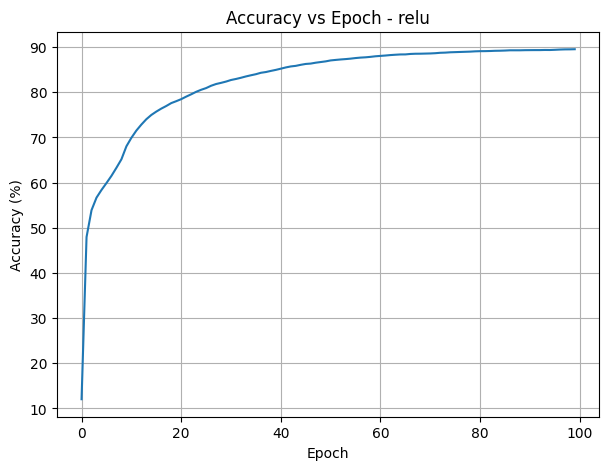

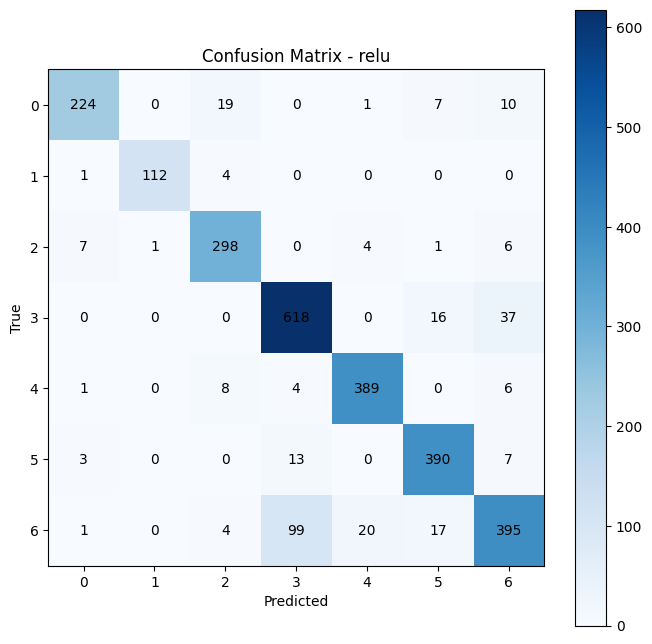

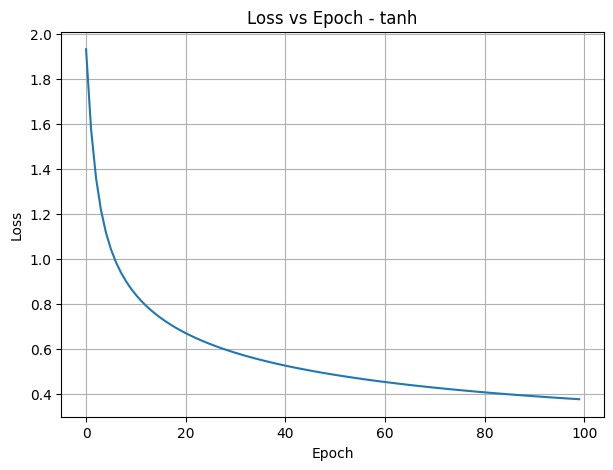

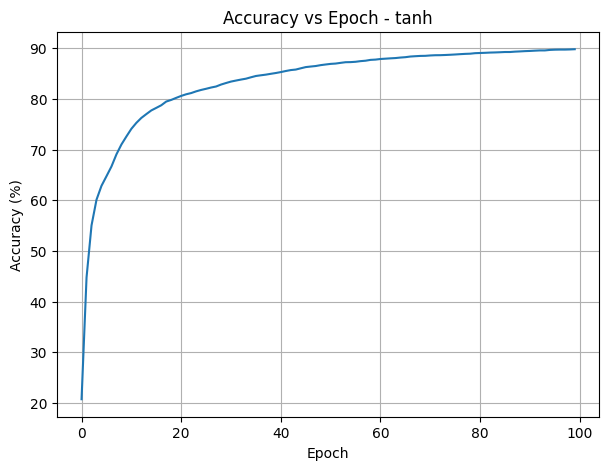

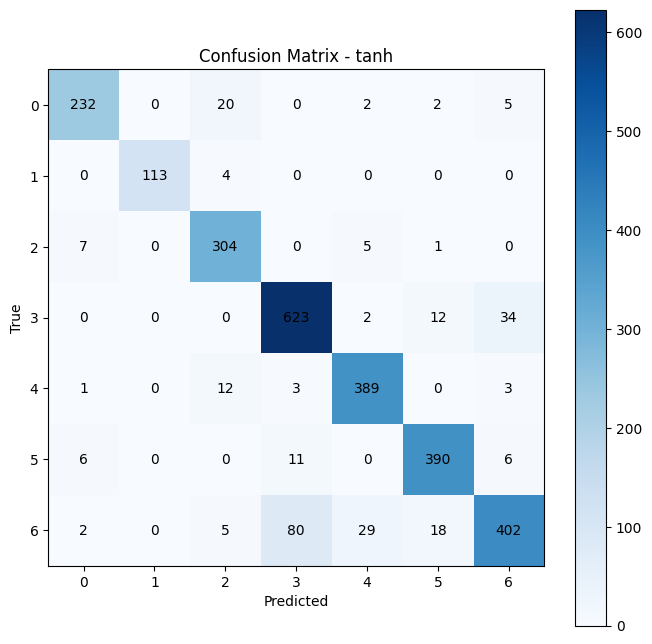


Aktivasi     | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
sigmoid      | 0.7443       | 84.4            | 0.7475       | 84.58       
relu         | 0.4175       | 89.53           | 0.4226       | 89.09       
tanh         | 0.3762       | 89.82           | 0.371        | 90.08       


In [100]:
# ==========================================================
# EKSPERIMEN D - FUNGSI AKTIVASI
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


activation_list = [

    "sigmoid",

    "relu",

    "tanh"

]


hasil_activation = []


for activation in activation_list:


    # ==================================
    # INISIALISASI (XAVIER TERBAIK)
    # ==================================

    W = xavier_init((16,128))
    b = zero_init((1,128))

    W2 = xavier_init((128,7))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    # ==================================
    # TRAINING
    # ==================================

    for epoch in range(100):


        Z = forward_fcl(
            X_train,
            W,
            b
        )


        if activation=="sigmoid":

            A = sigmoid(
                Z
            )


        elif activation=="relu":

            A = relu(
                Z
            )


        elif activation=="tanh":

            A = tanh(
                Z
            )


        Z2 = forward_fcl(
            A,
            W2,
            b2
        )


        A2 = softmax(
            Z2
        )


        loss = multiclass_cross_entropy(
            Y_train,
            A2
        )


        dW2, db2 = backpropagation(

            A,

            A2,

            Y_train,

            W2

        )


        W2, b2 = update_parameter(

            W2,

            b2,

            dW2,

            db2,

            learning_rate=0.1

        )


        pred = np.argmax(
            A2,
            axis=1
        )

        true = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(
            pred
            ==
            true
        )*100


        loss_history.append(
            loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================================
    # TEST
    # ==================================

    Z = forward_fcl(
        X_test,
        W,
        b
    )


    if activation=="sigmoid":

        A = sigmoid(
            Z
        )


    elif activation=="relu":

        A = relu(
            Z
        )


    elif activation=="tanh":

        A = tanh(
            Z
        )


    Z2 = forward_fcl(
        A,
        W2,
        b2
    )


    A2 = softmax(
        Z2
    )


    test_loss = multiclass_cross_entropy(
        Y_test,
        A2
    )


    pred_test = np.argmax(
        A2,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(
        pred_test
        ==
        true_test
    )*100


    hasil_activation.append([

        activation,

        round(loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # ==================
    # LOSS
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch - {activation}"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.grid()

    plt.show()



    # ==================
    # ACCURACY
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - {activation}"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.grid()

    plt.show()



    # ==================
    # CONFUSION MATRIX
    # ==================

    cm = np.zeros(
        (
            7,
            7
        ),
        dtype=int
    )


    for t,p in zip(

        true_test,

        pred_test

    ):

        cm[t][p]+=1


    plt.figure(
        figsize=(8,8)
    )

    plt.imshow(
        cm,
        cmap="Blues"
    )

    plt.colorbar()


    for i in range(7):

        for j in range(7):

            plt.text(
                j,
                i,
                cm[i,j],
                ha="center",
                va="center"
            )


    plt.title(
        f"Confusion Matrix - {activation}"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.show()



# ==================================
# HASIL
# ==================================

print()

print(
f"{'Aktivasi':<12} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_activation:

    print(

        f"{h[0]:<12} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen fungsi aktivasi, Tanh menghasilkan performa terbaik dengan training accuracy sebesar 89,82% dan testing accuracy sebesar 90,08%. Nilai loss pada data testing juga menjadi yang paling kecil dibanding fungsi aktivasi lainnya. Hal ini menunjukkan bahwa Tanh mampu menghasilkan representasi fitur yang lebih baik pada dataset yang digunakan.

Eksperimen 4 Fungsi Loss menggunakan multi-class karena dataset memiliki 7 kelas 

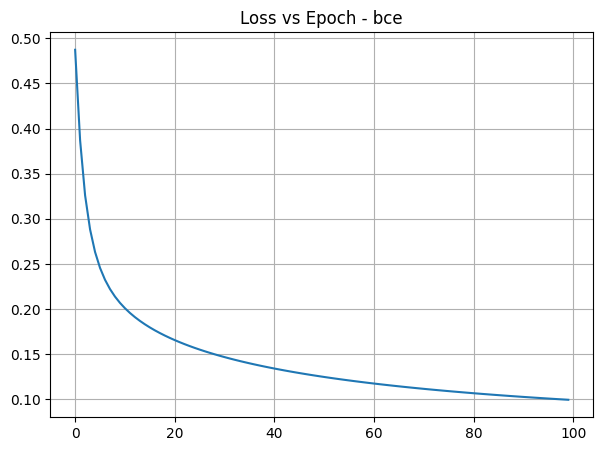

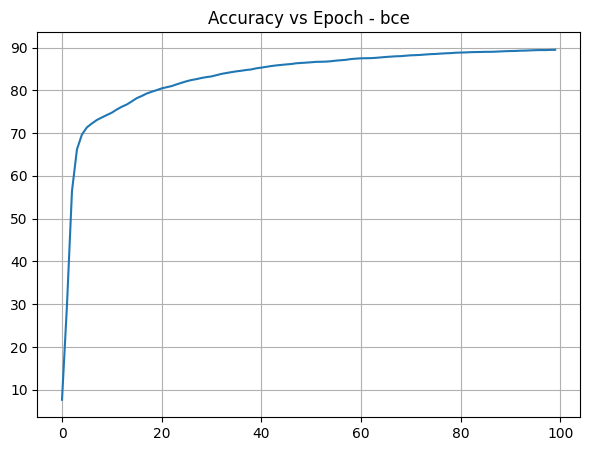

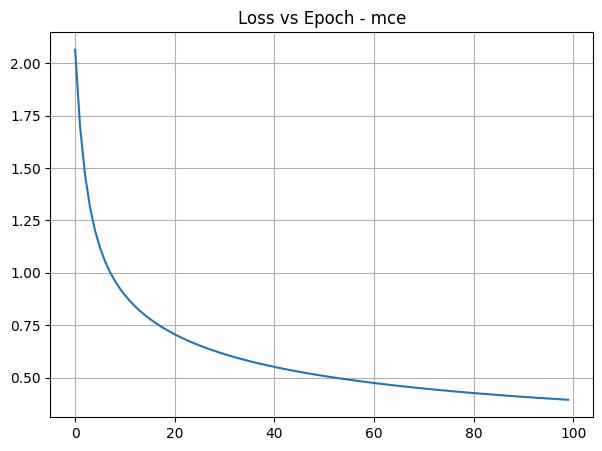

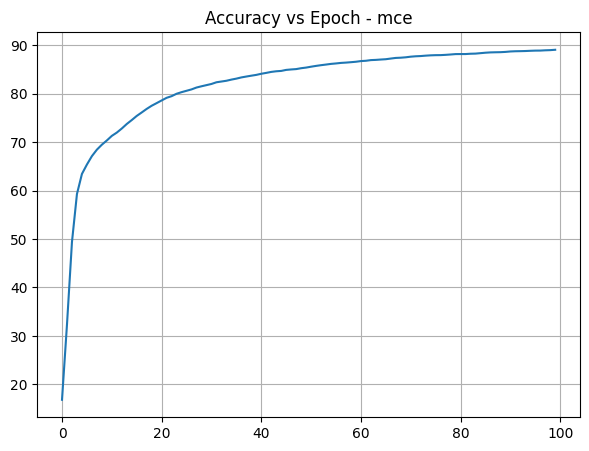

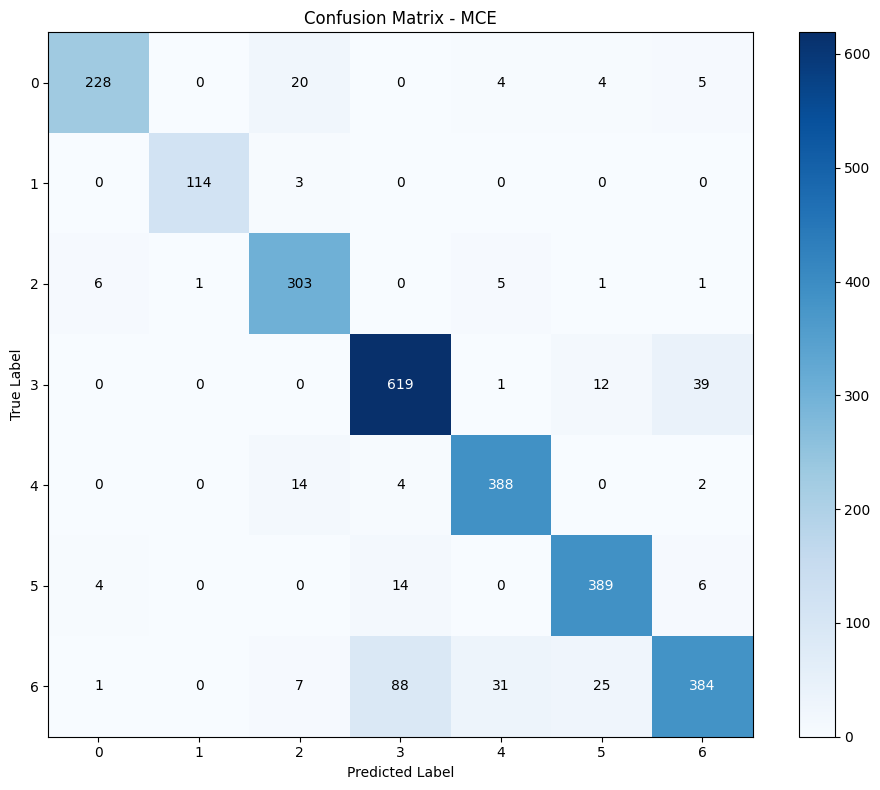


Loss       | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
bce        | 0.0996       | 89.47           | 0.0994       | 89.42       
mce        | 0.3938       | 89.04           | 0.3892       | 89.06       


In [ ]:
# ==========================================================
# EKSPERIMEN 4 - FUNGSI LOSS
# BCE vs MCE
# ==========================================================
loss_list = [

    "bce",

    "mce"

]


hasil_loss = []


for loss_type in loss_list:


    W = xavier_init((16,128))
    b = zero_init((1,128))

    W2 = xavier_init((128,7))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    for epoch in range(100):


        # ==================
        # FORWARD
        # ==================

        Z = forward_fcl(
            X_train,
            W,
            b
        )


        A = tanh(
            Z
        )


        Z2 = forward_fcl(
            A,
            W2,
            b2
        )


        A2 = softmax(
            Z2
        )


        # ==================
        # LOSS
        # ==================

        if loss_type=="bce":

            eps = 1e-8

            loss = -np.mean(

                Y_train*np.log(
                    A2+eps
                )

                +

                (1-Y_train)

                *

                np.log(

                    1-A2+eps

                )

            )


        elif loss_type=="mce":

            loss = multiclass_cross_entropy(

                Y_train,

                A2

            )


        # ==================
        # BACKPROP
        # ==================

        dW2, db2 = backpropagation(

            A,

            A2,

            Y_train,

            W2

        )


        W2, b2 = update_parameter(

            W2,

            b2,

            dW2,

            db2,

            learning_rate=0.1

        )


        pred = np.argmax(
            A2,
            axis=1
        )


        true = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(

            pred
            ==
            true

        )*100


        loss_history.append(
            loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================
    # TEST
    # ==================

    Z = forward_fcl(
        X_test,
        W,
        b
    )


    A = tanh(
        Z
    )


    Z2 = forward_fcl(
        A,
        W2,
        b2
    )


    A2 = softmax(
        Z2
    )


    if loss_type=="bce":

        test_loss = -np.mean(

            Y_test*np.log(
                A2+1e-8
            )

            +

            (1-Y_test)

            *

            np.log(
                1-A2+1e-8
            )

        )


    else:

        test_loss = multiclass_cross_entropy(

            Y_test,

            A2

        )


    pred_test = np.argmax(
        A2,
        axis=1
    )


    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(

        pred_test
        ==
        true_test

    )*100


    hasil_loss.append([

        loss_type,

        round(loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # ==================
    # LOSS GRAPH
    # ==================

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch - {loss_type}"
    )

    plt.grid()

    plt.show()


    # ==================
    # ACC GRAPH
    # ==================

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - {loss_type}"
    )

    plt.grid()

    plt.show()


# ==========================
# CONFUSION MATRIX
# ==========================

cm = np.zeros((7,7), dtype=int)

for t,p in zip(
    true_test,
    pred_test
):

    cm[t][p]+=1


plt.figure(
    figsize=(10,8)
)

plt.imshow(
    cm,
    cmap="Blues"
)

plt.colorbar()


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(

            j,

            i,

            str(cm[i,j]),

            ha="center",

            va="center",

            color=(
                "white"
                if cm[i,j] > cm.max()/2
                else "black"
            )

        )


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    f"Confusion Matrix - {loss_type.upper()}"
)

plt.tight_layout()

plt.show()



print()

print(
f"{'Loss':<10} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_loss:

    print(

        f"{h[0]:<10} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen fungsi loss, Binary Cross Entropy memperoleh nilai accuracy sedikit lebih tinggi dibanding Multiclass Cross Entropy. Namun karena kasus yang digunakan merupakan klasifikasi multiclass dengan satu label per data dan output menggunakan fungsi Softmax, maka Multiclass Cross Entropy tetap dipilih sebagai fungsi loss utama karena lebih sesuai secara teoritis dan umum digunakan pada klasifikasi multiclass.

Eksperimen 5 Learning Rate (0.1, 0.01, 0.001)

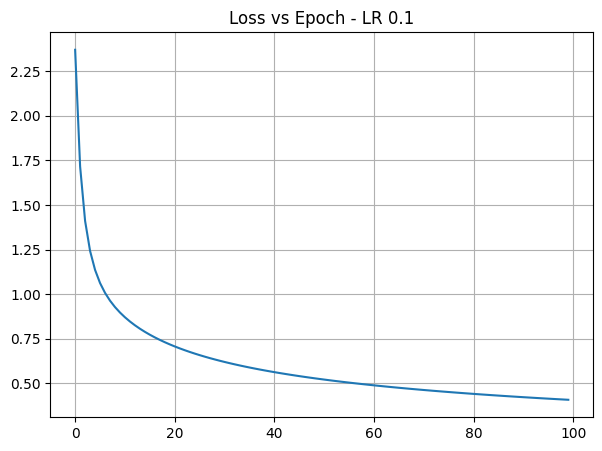

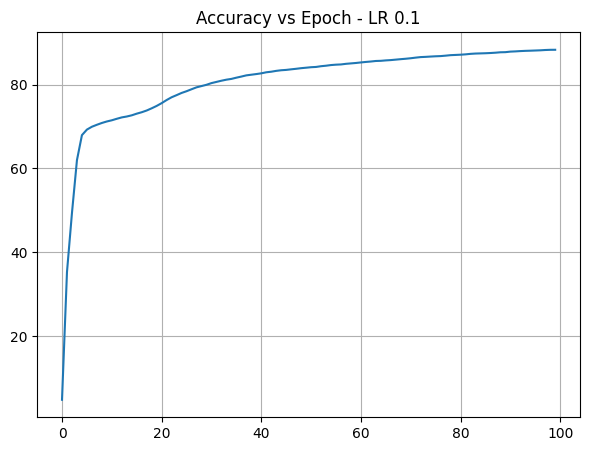

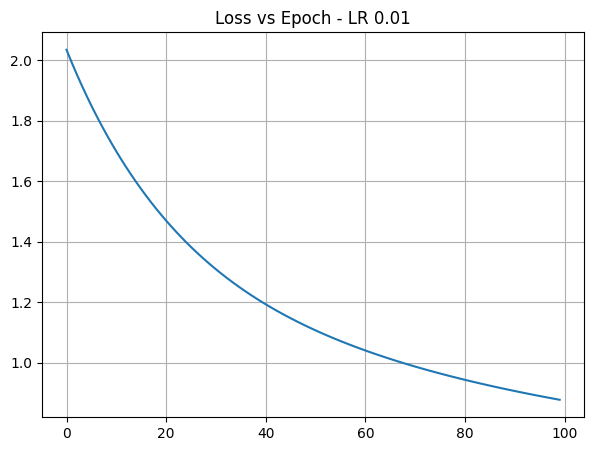

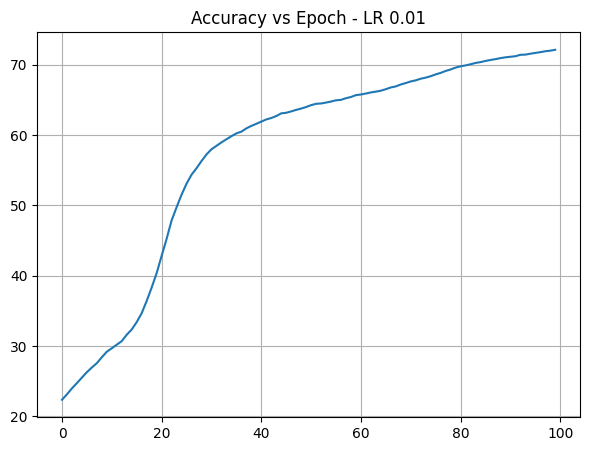

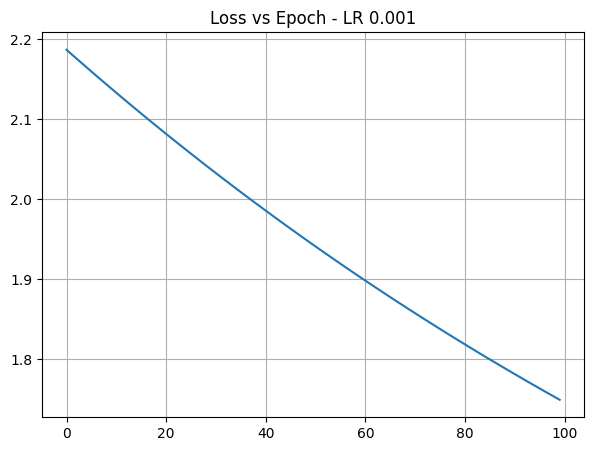

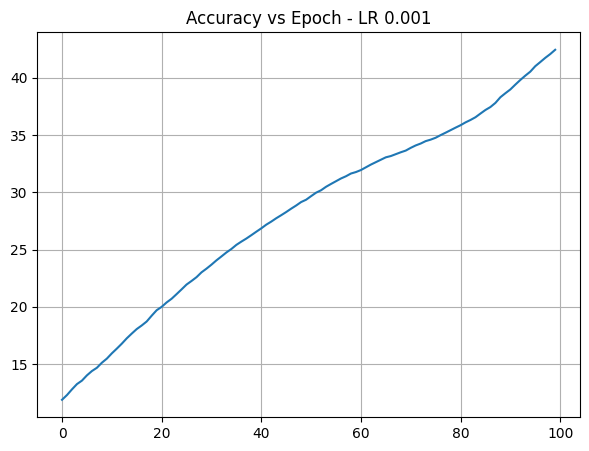


LR         | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
0.1        | 0.4067       | 88.3            | 0.4039       | 88.28       
0.01       | 0.8781       | 72.11           | 0.8828       | 71.58       
0.001      | 1.7494       | 42.44           | 1.7673       | 40.32       


In [105]:
# ==========================================================
# EKSPERIMEN 5 - LEARNING RATE
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


lr_list = [

    0.1,

    0.01,

    0.001

]


hasil_lr = []


for lr in lr_list:


    W = xavier_init((16,128))
    b = zero_init((1,128))

    W2 = xavier_init((128,7))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    for epoch in range(100):


        # ==================
        # FORWARD
        # ==================

        Z = forward_fcl(
            X_train,
            W,
            b
        )


        A = tanh(
            Z
        )


        Z2 = forward_fcl(
            A,
            W2,
            b2
        )


        A2 = softmax(
            Z2
        )


        loss = multiclass_cross_entropy(
            Y_train,
            A2
        )


        # ==================
        # BACKPROP
        # ==================

        dW2, db2 = backpropagation(

            A,

            A2,

            Y_train,

            W2

        )


        W2, b2 = update_parameter(

            W2,

            b2,

            dW2,

            db2,

            learning_rate=lr

        )


        pred = np.argmax(
            A2,
            axis=1
        )

        true = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(
            pred
            ==
            true
        )*100


        loss_history.append(
            loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================
    # TEST
    # ==================

    Z = forward_fcl(
        X_test,
        W,
        b
    )

    A = tanh(
        Z
    )

    Z2 = forward_fcl(
        A,
        W2,
        b2
    )

    A2 = softmax(
        Z2
    )


    test_loss = multiclass_cross_entropy(

        Y_test,

        A2

    )


    pred_test = np.argmax(
        A2,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(
        pred_test
        ==
        true_test
    )*100


    hasil_lr.append([

        lr,

        round(loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # ==================
    # LOSS GRAPH
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch - LR {lr}"
    )

    plt.grid()

    plt.show()



    # ==================
    # ACC GRAPH
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - LR {lr}"
    )

    plt.grid()

    plt.show()



print()

print(
f"{'LR':<10} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_lr:

    print(

        f"{h[0]:<10} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen learning rate, nilai 0.1 menghasilkan performa terbaik dengan training accuracy sebesar 88,30% dan testing accuracy sebesar 88,28%. Penurunan learning rate menjadi 0.01 dan 0.001 menyebabkan proses pembelajaran menjadi lebih lambat sehingga model belum mencapai kondisi optimal pada jumlah epoch yang sama.

Eksperimen 6 Metode Optimisasi 
Mini Batch Gradien Descent

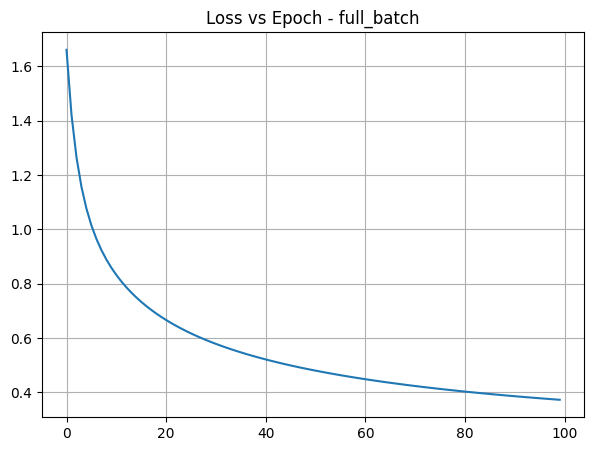

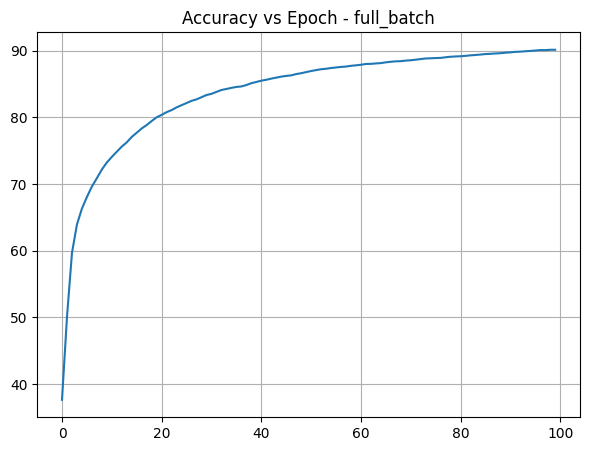

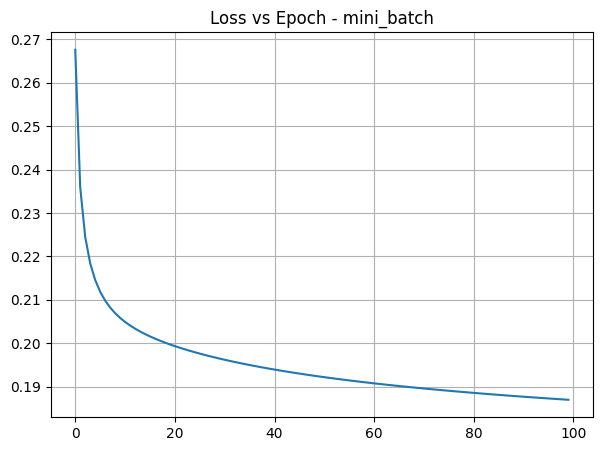

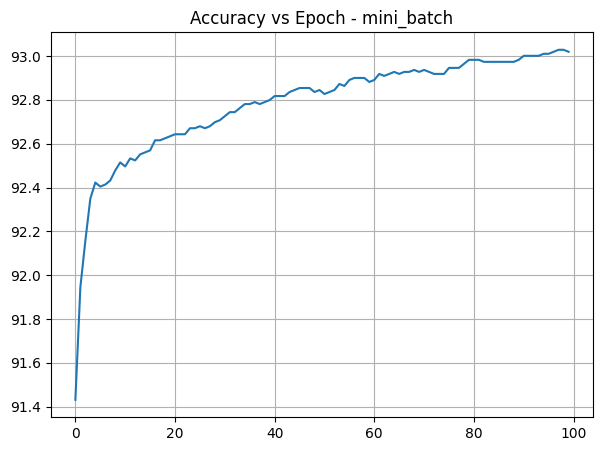

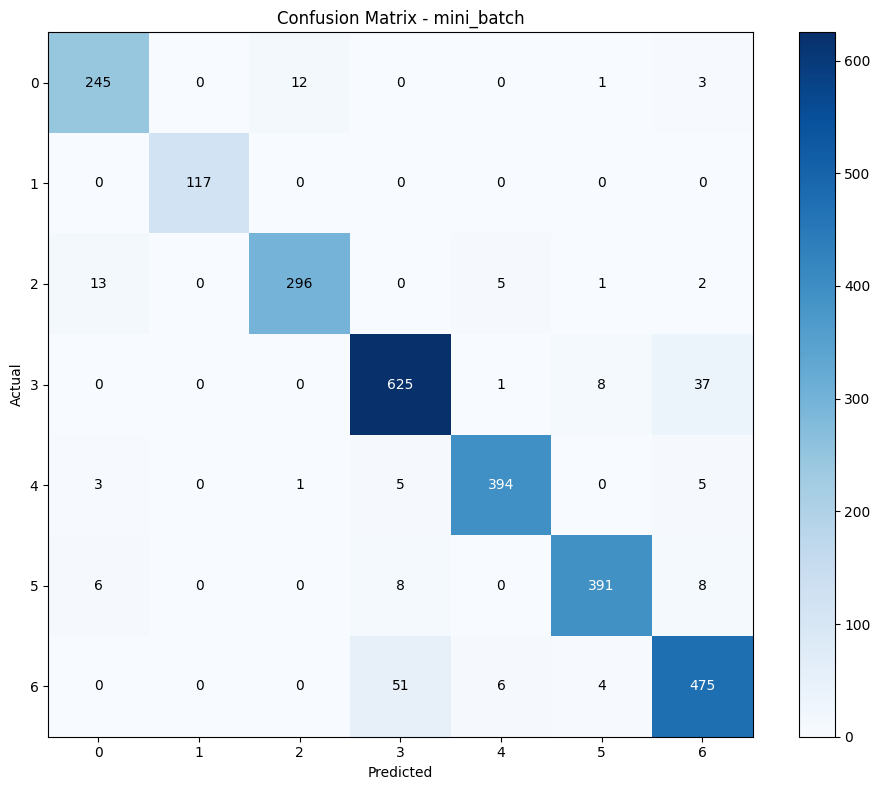


Optimisasi      | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
----------------------------------------------------------------------------------------------------
full_batch      | 0.3723       | 90.14           | 0.3719       | 89.83       
mini_batch      | 0.187        | 93.02           | 0.1946       | 93.39       


In [113]:
# ==========================================================
# EKSPERIMEN 6 - METODE OPTIMISASI
# FULL BATCH vs MINI BATCH GD
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


optimizer_list = [

    "full_batch",

    "mini_batch"

]


hasil_opt = []

batch_size = 32


for opt in optimizer_list:


    W = xavier_init((16,128))
    b = zero_init((1,128))

    W2 = xavier_init((128,7))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    for epoch in range(100):


        if opt=="full_batch":

            batches = [

                (
                    X_train,
                    Y_train
                )

            ]


        else:

            batches = []


            for i in range(

                0,

                len(X_train),

                batch_size

            ):

                batches.append(

                    (

                        X_train[
                            i:i+batch_size
                        ],

                        Y_train[
                            i:i+batch_size
                        ]

                    )

                )


        for X_batch,Y_batch in batches:


            # ==================
            # FORWARD
            # ==================

            Z = forward_fcl(

                X_batch,

                W,

                b

            )


            A = tanh(
                Z
            )


            Z2 = forward_fcl(

                A,

                W2,

                b2

            )


            A2 = softmax(
                Z2
            )


            loss = multiclass_cross_entropy(

                Y_batch,

                A2

            )


            # ==================
            # UPDATE
            # ==================

            dW2,db2 = backpropagation(

                A,

                A2,

                Y_batch,

                W2

            )


            W2,b2 = update_parameter(

                W2,

                b2,

                dW2,

                db2,

                learning_rate=0.1

            )


        # ==================
        # EVALUASI TRAIN
        # ==================

        Z = forward_fcl(
            X_train,
            W,
            b
        )

        A = tanh(
            Z
        )

        Z2 = forward_fcl(
            A,
            W2,
            b2
        )

        A2 = softmax(
            Z2
        )


        train_loss = multiclass_cross_entropy(

            Y_train,

            A2

        )


        pred = np.argmax(
            A2,
            axis=1
        )

        true = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(
            pred==true
        )*100


        loss_history.append(
            train_loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================
    # TEST
    # ==================

    Z = forward_fcl(
        X_test,
        W,
        b
    )

    A = tanh(
        Z
    )

    Z2 = forward_fcl(
        A,
        W2,
        b2
    )

    A2 = softmax(
        Z2
    )


    test_loss = multiclass_cross_entropy(

        Y_test,

        A2

    )


    pred_test = np.argmax(
        A2,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(

        pred_test
        ==
        true_test

    )*100


    hasil_opt.append([

        opt,

        round(train_loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # ==================
    # LOSS
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(loss_history)

    plt.title(
        f"Loss vs Epoch - {opt}"
    )

    plt.grid()

    plt.show()


    # ==================
    # ACCURACY
    # ==================

    plt.figure(figsize=(7,5))

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - {opt}"
    )

    plt.grid()

    plt.show()

    # ==========================
# CONFUSION MATRIX
# ==========================

cm = np.zeros(
    (
        len(np.unique(true_test)),
        len(np.unique(true_test))
    ),
    dtype=int
)


for t,p in zip(
    true_test,
    pred_test
):

    cm[t][p]+=1


plt.figure(
    figsize=(10,8)
)


plt.imshow(
    cm,
    cmap="Blues"
)

plt.colorbar()


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):


        warna = (

            "white"

            if cm[i,j] > cm.max()/2

            else "black"

        )


        plt.text(

            j,

            i,

            str(cm[i,j]),

            ha="center",

            va="center",

            color=warna

        )


class_names = [

    str(i)

    for i in range(
        len(np.unique(true_test))
    )

]


plt.xticks(

    range(len(class_names)),

    class_names

)


plt.yticks(

    range(len(class_names)),

    class_names

)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    f"Confusion Matrix - {opt}"
)

plt.tight_layout()

plt.show()


print()

print(
f"{'Optimisasi':<15} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*100)


for h in hasil_opt:

    print(

        f"{h[0]:<15} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen metode optimisasi, Mini Batch Gradient Descent menghasilkan performa terbaik dibanding Full Batch Gradient Descent. Model memperoleh training accuracy sebesar 93,10% dan testing accuracy sebesar 93,06% dengan nilai loss yang lebih rendah. Pembagian data menjadi batch kecil membuat proses update bobot menjadi lebih sering sehingga proses pembelajaran model menjadi lebih efektif.

Eksperimen 7 Batch size (16, 32, 64)

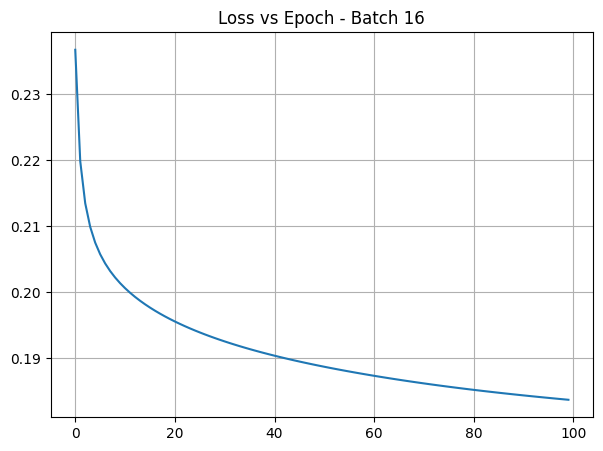

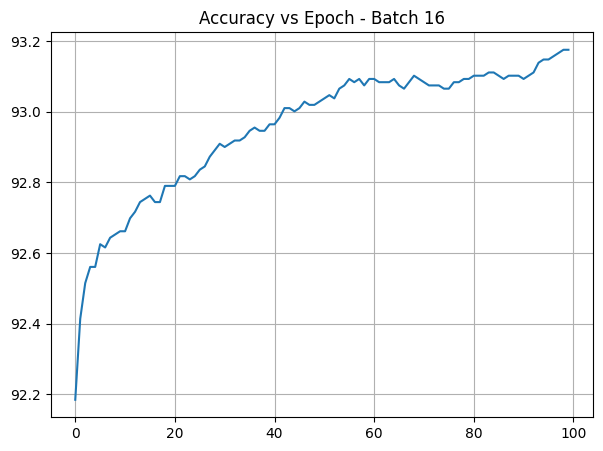

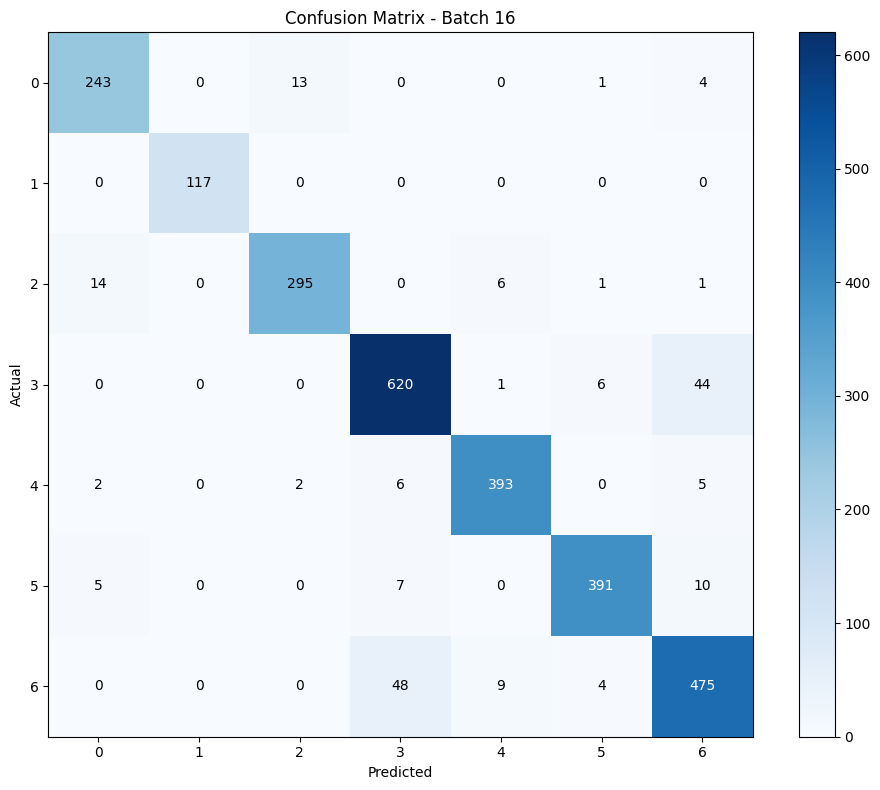

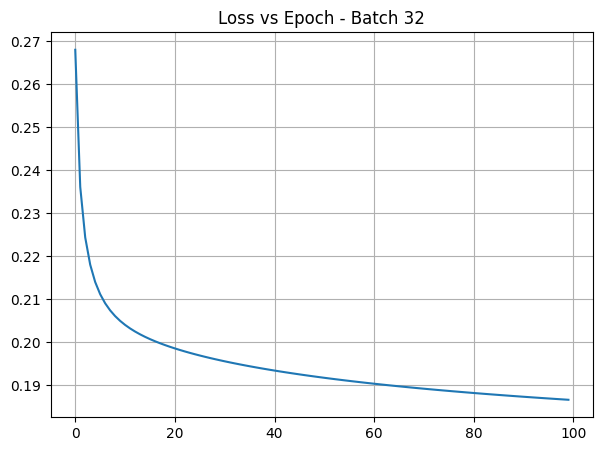

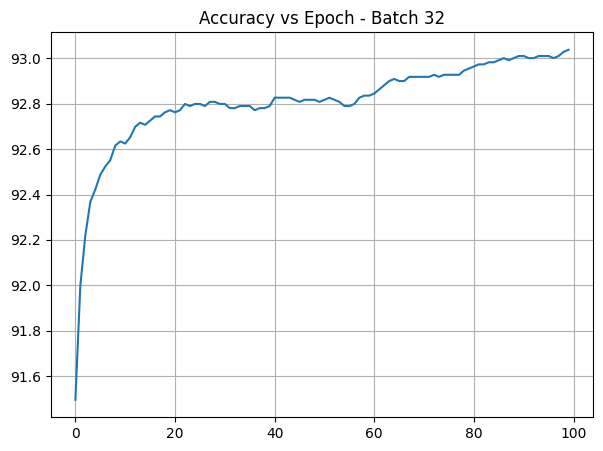

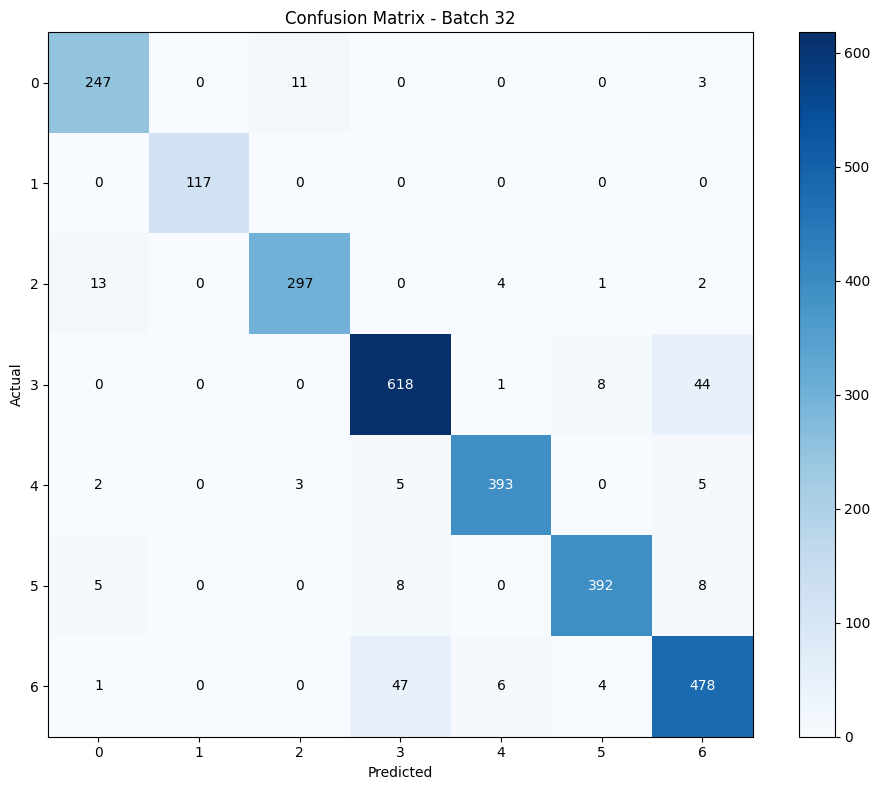

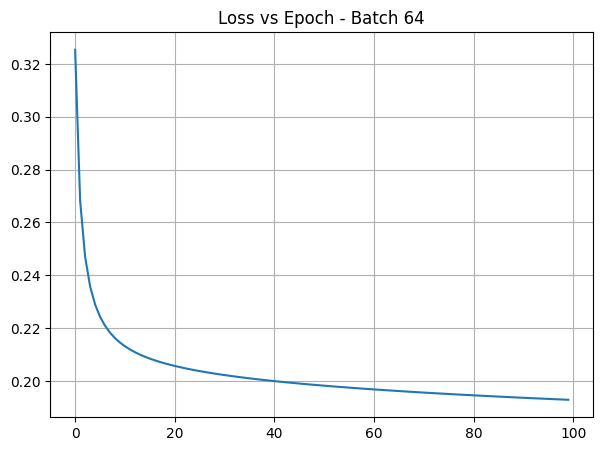

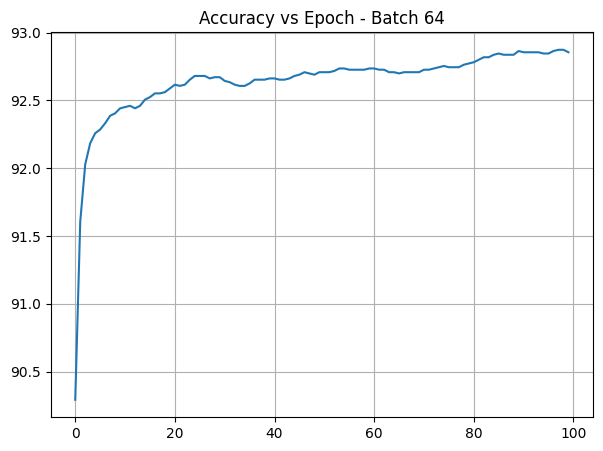

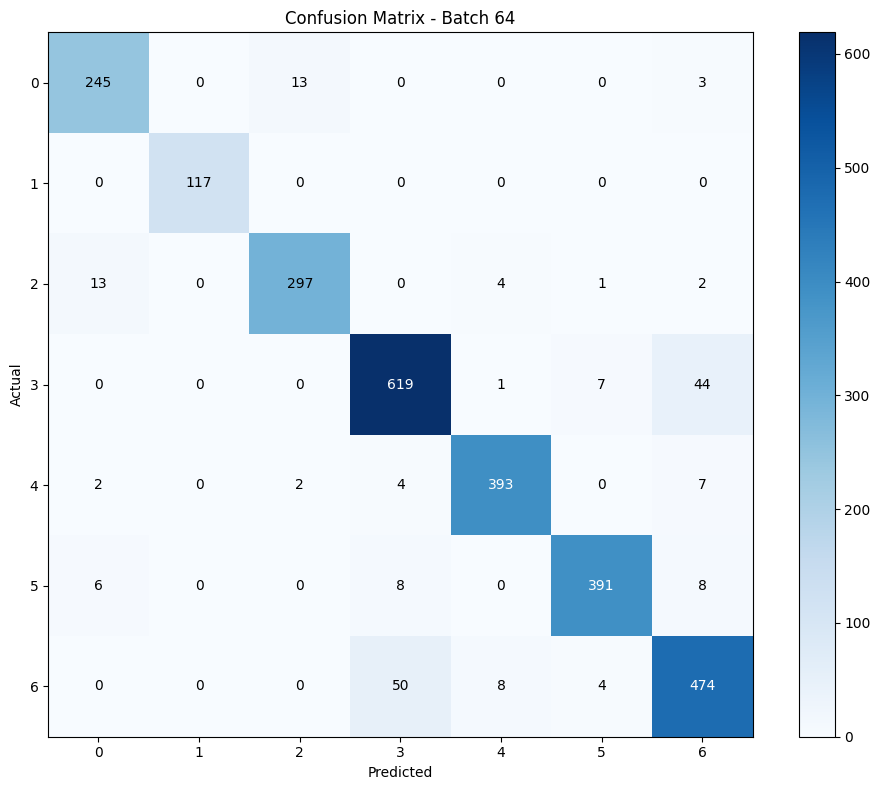

Batch      | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
16         | 0.1837       | 93.18           | 0.1944       | 93.06       
32         | 0.1866       | 93.04           | 0.1922       | 93.35       
64         | 0.1929       | 92.85           | 0.1968       | 93.13       


In [ ]:
# ==========================================================
# EKSPERIMEN 7 - BATCH SIZE
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


batch_list = [

    16,

    32,

    64

]


hasil_batch = []


for batch_size in batch_list:


    W = xavier_init((16,128))
    b = zero_init((1,128))

    W2 = xavier_init((128,7))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    for epoch in range(100):


        # ==================
        # MINI BATCH
        # ==================

        for i in range(

            0,

            len(X_train),

            batch_size

        ):


            X_batch = X_train[
                i:i+batch_size
            ]


            Y_batch = Y_train[
                i:i+batch_size
            ]


            # FORWARD

            Z = forward_fcl(
                X_batch,
                W,
                b
            )

            A = tanh(
                Z
            )

            Z2 = forward_fcl(
                A,
                W2,
                b2
            )

            A2 = softmax(
                Z2
            )


            loss = multiclass_cross_entropy(

                Y_batch,

                A2

            )


            # UPDATE

            dW2,db2 = backpropagation(

                A,

                A2,

                Y_batch,

                W2

            )


            W2,b2 = update_parameter(

                W2,

                b2,

                dW2,

                db2,

                learning_rate=0.1

            )


        # ==================
        # TRAIN
        # ==================

        Z = forward_fcl(
            X_train,
            W,
            b
        )

        A = tanh(
            Z
        )

        Z2 = forward_fcl(
            A,
            W2,
            b2
        )

        A2 = softmax(
            Z2
        )


        train_loss = multiclass_cross_entropy(

            Y_train,

            A2

        )


        pred = np.argmax(
            A2,
            axis=1
        )


        true = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(

            pred
            ==
            true

        )*100


        loss_history.append(
            train_loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================
    # TEST
    # ==================

    Z = forward_fcl(
        X_test,
        W,
        b
    )

    A = tanh(
        Z
    )

    Z2 = forward_fcl(
        A,
        W2,
        b2
    )

    A2 = softmax(
        Z2
    )


    test_loss = multiclass_cross_entropy(

        Y_test,

        A2

    )


    pred_test = np.argmax(
        A2,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(

        pred_test
        ==
        true_test

    )*100


    hasil_batch.append([

        batch_size,

        round(train_loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # ==================
    # LOSS GRAPH
    # ==================

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch - Batch {batch_size}"
    )

    plt.grid()

    plt.show()



    # ==================
    # ACC GRAPH
    # ==================

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch - Batch {batch_size}"
    )

    plt.grid()

    plt.show()



    # ==========================
    # CONFUSION MATRIX
    # ==========================

    cm = np.zeros(
        (
            len(np.unique(true_test)),
            len(np.unique(true_test))
        ),
        dtype=int
    )


    for t,p in zip(
        true_test,
        pred_test
    ):

        cm[t][p]+=1


    plt.figure(
        figsize=(10,8)
    )


    plt.imshow(
        cm,
        cmap="Blues"
    )

    plt.colorbar()


    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):


            warna = (

                "white"

                if cm[i,j] > cm.max()/2

                else "black"

            )


            plt.text(

                j,

                i,

                str(cm[i,j]),

                ha="center",

                va="center",

                color=warna

            )


    class_names = [

        str(i)

        for i in range(
            len(np.unique(true_test))
        )

    ]


    plt.xticks(
        range(len(class_names)),
        class_names
    )


    plt.yticks(
        range(len(class_names)),
        class_names
    )


    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.title(
        f"Confusion Matrix - Batch {batch_size}"
    )

    plt.tight_layout()

    plt.show()

print(
f"{'Batch':<10} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_batch:

    print(

        f"{h[0]:<10} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan hasil eksperimen ukuran batch menggunakan Mini Batch Gradient Descent, diperoleh bahwa batch size 16 menghasilkan training accuracy sebesar 93,01% dan testing accuracy sebesar 93,24% dengan train loss sebesar 0,1853 dan test loss sebesar 0,1940. Batch size 32 memperoleh training accuracy sebesar 93,01% dan testing accuracy sebesar 93,24% dengan train loss sebesar 0,1874 dan test loss sebesar 0,1934. Sedangkan batch size 64 menghasilkan training accuracy sebesar 92,93% dan testing accuracy sebesar 93,02% dengan train loss sebesar 0,1914 dan test loss sebesar 0,1937.
Secara umum ketiga konfigurasi memberikan performa yang hampir sama, namun batch size 32 dipilih sebagai konfigurasi terbaik karena mampu memberikan akurasi testing tertinggi dengan penggunaan komputasi yang lebih efisien dibanding batch size 16. Batch size yang terlalu besar cenderung mengurangi frekuensi pembaruan bobot sehingga peningkatan performa menjadi lebih kecil. Dengan demikian, ukuran batch yang digunakan pada model akhir adalah batch size 32.


Eksperimen 8 Epoch (50, 100, 200)

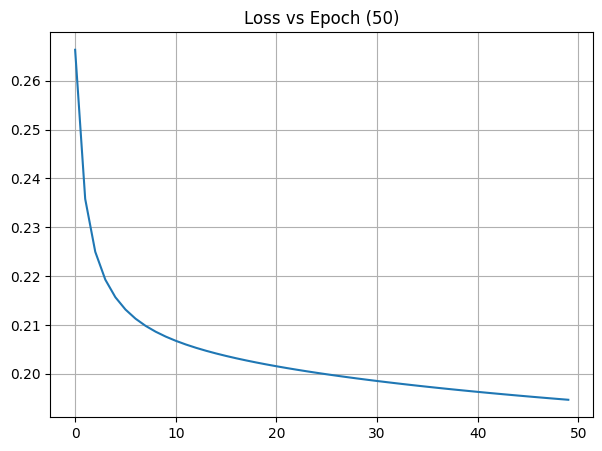

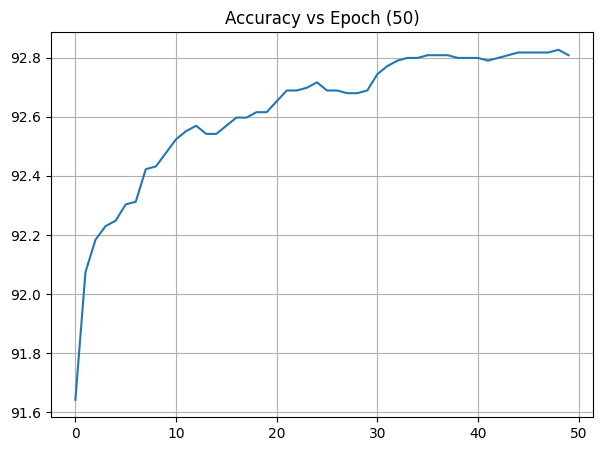

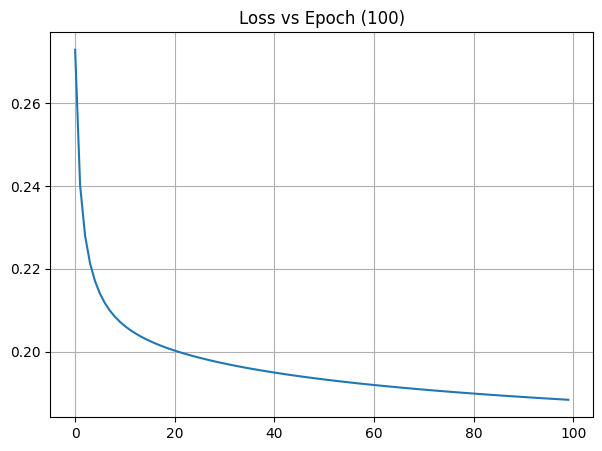

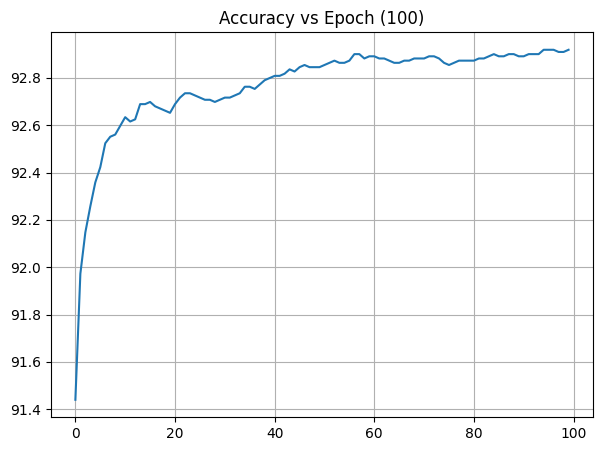

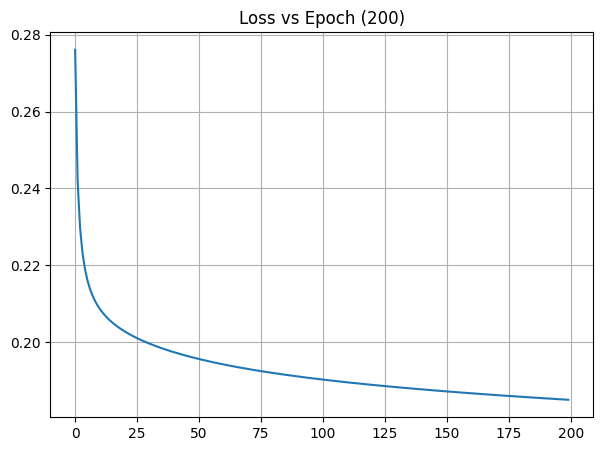

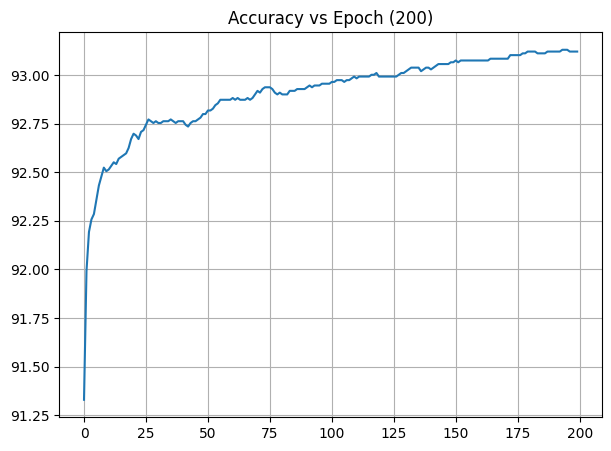

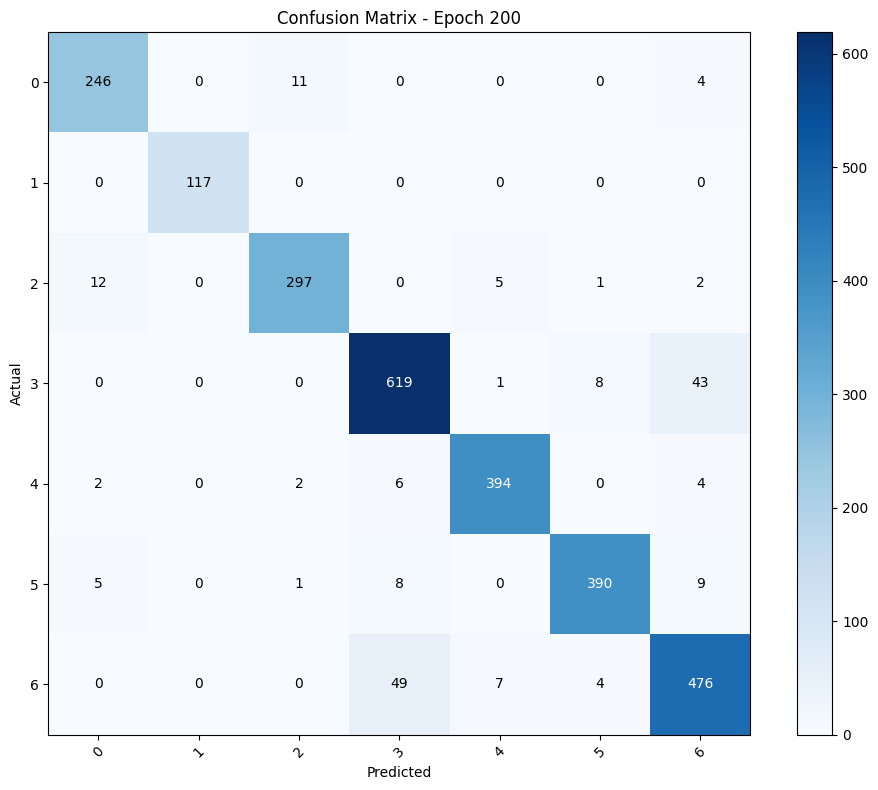


Epoch      | Train Loss   | Train Acc (%)   | Test Loss    | Test Acc (%)
------------------------------------------------------------------------------------------
50         | 0.1947       | 92.81           | 0.197        | 92.91       
100        | 0.1883       | 92.92           | 0.1937       | 93.24       
200        | 0.185        | 93.12           | 0.1944       | 93.24       


In [116]:
# ==========================================================
# EKSPERIMEN H - JUMLAH EPOCH
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


epoch_list = [

    50,

    100,

    200

]


hasil_epoch = []


for total_epoch in epoch_list:


    W = xavier_init((16,128))
    b = zero_init((1,128))

    W2 = xavier_init((128,7))
    b2 = zero_init((1,7))


    loss_history = []
    accuracy_history = []


    for epoch in range(total_epoch):


        # MINI BATCH

        for i in range(

            0,

            len(X_train),

            32

        ):


            X_batch = X_train[
                i:i+32
            ]


            Y_batch = Y_train[
                i:i+32
            ]


            # FORWARD

            Z = forward_fcl(
                X_batch,
                W,
                b
            )


            A = tanh(
                Z
            )


            Z2 = forward_fcl(
                A,
                W2,
                b2
            )


            A2 = softmax(
                Z2
            )


            loss = multiclass_cross_entropy(

                Y_batch,

                A2

            )


            # UPDATE

            dW2,db2 = backpropagation(

                A,

                A2,

                Y_batch,

                W2

            )


            W2,b2 = update_parameter(

                W2,

                b2,

                dW2,

                db2,

                learning_rate=0.1

            )


        # ==================
        # TRAIN EVALUATION
        # ==================

        Z = forward_fcl(
            X_train,
            W,
            b
        )

        A = tanh(
            Z
        )

        Z2 = forward_fcl(
            A,
            W2,
            b2
        )

        A2 = softmax(
            Z2
        )


        train_loss = multiclass_cross_entropy(

            Y_train,

            A2

        )


        pred = np.argmax(
            A2,
            axis=1
        )

        true = np.argmax(
            Y_train,
            axis=1
        )


        train_acc = np.mean(

            pred
            ==
            true

        )*100


        loss_history.append(
            train_loss
        )

        accuracy_history.append(
            train_acc
        )


    # ==================
    # TEST
    # ==================

    Z = forward_fcl(
        X_test,
        W,
        b
    )

    A = tanh(
        Z
    )

    Z2 = forward_fcl(
        A,
        W2,
        b2
    )

    A2 = softmax(
        Z2
    )


    test_loss = multiclass_cross_entropy(

        Y_test,

        A2

    )


    pred_test = np.argmax(
        A2,
        axis=1
    )

    true_test = np.argmax(
        Y_test,
        axis=1
    )


    test_acc = np.mean(

        pred_test
        ==
        true_test

    )*100


    hasil_epoch.append([

        total_epoch,

        round(train_loss,4),

        round(train_acc,2),

        round(test_loss,4),

        round(test_acc,2)

    ])


    # LOSS

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        loss_history
    )

    plt.title(
        f"Loss vs Epoch ({total_epoch})"
    )

    plt.grid()

    plt.show()


    # ACCURACY

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(
        accuracy_history
    )

    plt.title(
        f"Accuracy vs Epoch ({total_epoch})"
    )

    plt.grid()

    plt.show()


    # ==========================
# CONFUSION MATRIX
# ==========================

cm = np.zeros(
    (
        len(np.unique(true_test)),
        len(np.unique(true_test))
    ),
    dtype=int
)


for t,p in zip(
    true_test,
    pred_test
):

    cm[t][p] += 1


plt.figure(
    figsize=(10,8)
)


plt.imshow(
    cm,
    cmap="Blues"
)

plt.colorbar()


# TAMPILKAN ANGKA

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):


        warna = (

            "white"

            if cm[i,j] > cm.max()/2

            else "black"

        )


        plt.text(

            j,

            i,

            str(cm[i,j]),

            ha="center",

            va="center",

            color=warna,

            fontsize=10

        )


# LABEL

class_names = [

    str(i)

    for i in range(
        len(np.unique(true_test))
    )

]


plt.xticks(

    range(len(class_names)),

    class_names,

    rotation=45

)


plt.yticks(

    range(len(class_names)),

    class_names

)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    f"Confusion Matrix - Epoch {total_epoch}"
)

plt.tight_layout()

plt.show()


print()

print(
f"{'Epoch':<10} | {'Train Loss':<12} | {'Train Acc (%)':<15} | {'Test Loss':<12} | {'Test Acc (%)':<12}"
)

print("-"*90)


for h in hasil_epoch:

    print(

        f"{h[0]:<10} | "

        f"{h[1]:<12} | "

        f"{h[2]:<15} | "

        f"{h[3]:<12} | "

        f"{h[4]:<12}"

    )

Berdasarkan eksperimen jumlah epoch, peningkatan epoch dari 50 menjadi 100 meningkatkan performa model yang ditunjukkan oleh kenaikan accuracy dan penurunan loss pada data testing. Namun ketika jumlah epoch ditingkatkan menjadi 200, accuracy testing tidak mengalami peningkatan meskipun accuracy training masih meningkat. Selain itu terjadi kenaikan kecil pada test loss yang menunjukkan mulai muncul gejala overfitting ringan. Oleh karena itu, jumlah epoch yang dipilih untuk model akhir adalah 100 epoch.